In [1]:
# ==============================================================================
# IMPORT LIBRARIES
# ==============================================================================

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Numerical Operations
import numpy as np

# Data Manipulation
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [2]:
# ==============================================================================
# NOTEBOOK CONFIGURATION
# ==============================================================================

# Display all columns
pd.set_option("display.max_columns", None)

# Display more rows
pd.set_option("display.max_rows", 100)

# Display decimal points
pd.set_option("display.float_format", "{:.2f}".format)

# Figure Size
plt.rcParams["figure.figsize"] = (8,5)

# Resolution
plt.rcParams["figure.dpi"] = 120

# Style
plt.style.use("ggplot")

# Seaborn Theme
sns.set_theme(style="whitegrid")

print("✅ Notebook configured.")

✅ Notebook configured.


In [4]:
df = pd.read_csv('/Users/amangadhiya/Desktop/ML Projects/mental_health_app/data/student_social_media_mental_health.csv')

In [6]:
# ==============================================================================
# LOAD DATASET
# ==============================================================================

DATASET_PATH = '/Users/amangadhiya/Desktop/ML Projects/mental_health_app/data/student_social_media_mental_health.csv'

df = pd.read_csv(DATASET_PATH)

print("✅ Dataset Loaded Successfully.")

✅ Dataset Loaded Successfully.


In [7]:
# ==============================================================================
# DATASET SHAPE
# ==============================================================================

rows, columns = df.shape

print(f"Total Rows    : {rows}")
print(f"Total Columns : {columns}")

Total Rows    : 5000
Total Columns : 13


In [8]:
# ==============================================================================
# COLUMN NAMES
# ==============================================================================

print("Columns Present in Dataset\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns Present in Dataset

1. Age
2. Gender
3. Country
4. Academic_Level
5. Most_Used_Platform
6. Purpose_Of_Use
7. Avg_Daily_Usage_Hours
8. Daily_Unlocks
9. Study_Hours
10. Physical_Activity_Hours
11. Sleep_Hours_Per_Night
12. Stress_Level
13. Mental_Health_Score


In [9]:
# ==============================================================================
# PREVIEW DATASET
# ==============================================================================

print("First Five Records\n")

display(df.head())

First Five Records



,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.00,134,4.50,2.20,6.70,Medium,6.80
1,23,Female,Other,Graduate,LinkedIn,Education,1.60,73,7.00,2.40,8.60,Low,7.60
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.60,166,4.00,1.80,6.70,Medium,7.00
3,18,Male,Other,High School,Snapchat,Entertainment,7.00,220,1.00,1.70,5.40,Very High,5.30
4,24,Female,Other,Graduate,Facebook,Networking,7.50,237,1.00,1.10,5.00,Very High,4.40


In [10]:
# ==============================================================================
# RANDOM SAMPLE
# ==============================================================================

display(df.sample(5, random_state=42))

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
1501,21,Male,China,Undergraduate,WeChat,Entertainment,4.50,145,2.70,2.60,7.80,High,7.00
2586,21,Male,Denmark,Undergraduate,Facebook,Networking,3.40,116,5.70,2.60,8.80,Medium,8.10
2653,20,Female,Peru,Undergraduate,TikTok,Entertainment,5.60,192,3.90,1.90,5.60,High,5.10
1055,20,Female,Jamaica,Undergraduate,Snapchat,Entertainment,4.90,158,3.40,1.40,5.60,High,6.00
705,19,Male,UK,Undergraduate,Snapchat,Entertainment,3.80,140,3.20,2.50,6.60,Low,6.80


In [12]:
# ==============================================================================
# DATASET INFORMATION
# ==============================================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [13]:
# ==============================================================================
# STATISTICAL SUMMARY
# ==============================================================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,5000.00,20.82,1.74,18.00,19.00,21.00,22.00,24.00
Avg_Daily_Usage_Hours,5000.00,5.08,1.65,1.00,3.80,5.00,6.30,8.80
Daily_Unlocks,5000.00,171.45,42.86,62.00,140.00,171.00,204.00,273.00
Study_Hours,5000.00,3.01,1.64,0.30,1.50,2.80,4.20,8.30
Physical_Activity_Hours,5000.00,1.75,0.67,-0.40,1.30,1.70,2.20,4.10
Sleep_Hours_Per_Night,5000.00,6.63,1.22,3.60,5.60,6.60,7.50,9.90
Mental_Health_Score,5000.00,6.23,1.28,3.60,5.10,6.10,7.10,9.40


In [14]:
# ==============================================================================
# CATEGORICAL FEATURES
# ==============================================================================

categorical_columns = df.select_dtypes(include="object")

display(categorical_columns.describe().T)

,count,unique,top,freq
Gender,5000,2,Male,2635
Country,5000,111,Other,1880
Academic_Level,5000,3,Undergraduate,3632
Most_Used_Platform,5000,12,Instagram,1130
Purpose_Of_Use,5000,4,Entertainment,2552
Stress_Level,5000,4,Very High,1621


In [15]:
# ==============================================================================
# MISSING VALUES
# ==============================================================================

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing_values = missing_values.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_values)

,Missing Values,Percentage
Age,0,0.00
Gender,0,0.00
Country,0,0.00
Academic_Level,0,0.00
Most_Used_Platform,0,0.00
Purpose_Of_Use,0,0.00
Avg_Daily_Usage_Hours,0,0.00
Daily_Unlocks,0,0.00
Study_Hours,0,0.00
Physical_Activity_Hours,0,0.00


In [16]:
# ==============================================================================
# DUPLICATE RECORDS
# ==============================================================================

duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 2


In [17]:
# ==============================================================================
# MEMORY USAGE
# ==============================================================================

memory_usage = df.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"Dataset Memory Usage : {memory_usage:.2f} MB")

Dataset Memory Usage : 1.89 MB


In [18]:
# ==============================================================================
# TARGET VARIABLE
# ==============================================================================

TARGET = "Mental_Health_Score"

print(df[TARGET].describe())

count   5000.00
mean       6.23
std        1.28
min        3.60
25%        5.10
50%        6.10
75%        7.10
max        9.40
Name: Mental_Health_Score, dtype: float64


In [19]:
# ==============================================================================
# FEATURE TYPES
# ==============================================================================

numerical_features = df.select_dtypes(include=np.number).columns.tolist()

categorical_features = df.select_dtypes(include="object").columns.tolist()

print(f"Numerical Features   : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

Numerical Features   : 7
Categorical Features : 6


In [20]:
# ==============================================================================
# UNIQUE VALUES
# ==============================================================================

for column in categorical_features:

    print("-" * 60)

    print(f"{column}")

    print(df[column].nunique(), "Unique Values")

------------------------------------------------------------
Gender
2 Unique Values
------------------------------------------------------------
Country
111 Unique Values
------------------------------------------------------------
Academic_Level
3 Unique Values
------------------------------------------------------------
Most_Used_Platform
12 Unique Values
------------------------------------------------------------
Purpose_Of_Use
4 Unique Values
------------------------------------------------------------
Stress_Level
4 Unique Values


In [21]:
# ==============================================================================
# PROJECT SUMMARY
# ==============================================================================

print("="*70)

print("Dataset Loaded Successfully")

print(f"Shape                : {df.shape}")

print(f"Missing Values       : {df.isnull().sum().sum()}")

print(f"Duplicate Records    : {df.duplicated().sum()}")

print(f"Numerical Features   : {len(numerical_features)}")

print(f"Categorical Features : {len(categorical_features)}")

print("="*70)

Dataset Loaded Successfully
Shape                : (5000, 13)
Missing Values       : 0
Duplicate Records    : 2
Numerical Features   : 7
Categorical Features : 6


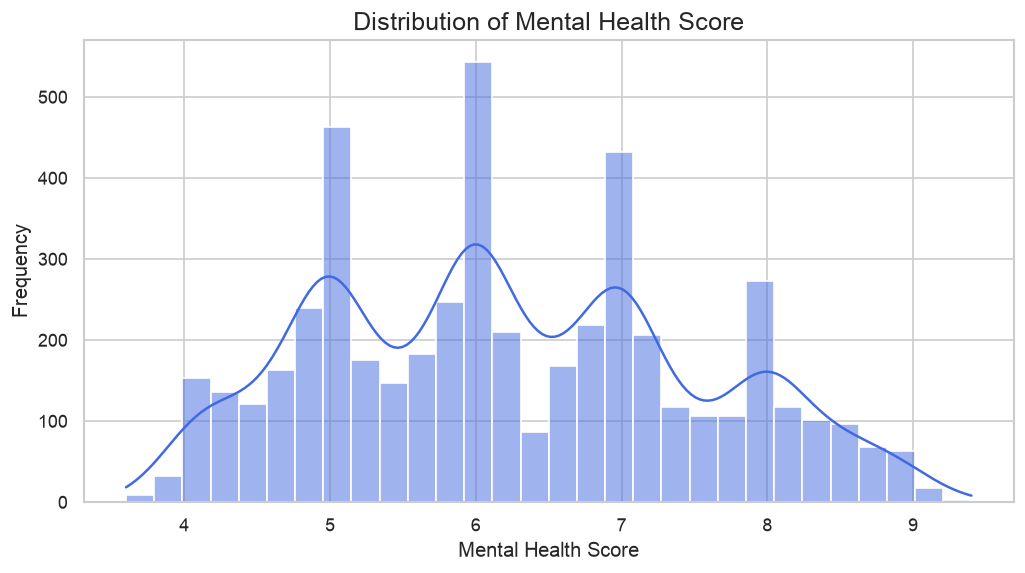

In [22]:
# ==============================================================================
# TARGET VARIABLE DISTRIBUTION
# ==============================================================================

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Mental_Health_Score",
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Mental Health Score", fontsize=15)
plt.xlabel("Mental Health Score")
plt.ylabel("Frequency")

plt.show()

In [23]:
# ==============================================================================
# TARGET VARIABLE SUMMARY
# ==============================================================================

print(df["Mental_Health_Score"].describe())

print("\nSkewness :", df["Mental_Health_Score"].skew())

print("Kurtosis :", df["Mental_Health_Score"].kurt())

count   5000.00
mean       6.23
std        1.28
min        3.60
25%        5.10
50%        6.10
75%        7.10
max        9.40
Name: Mental_Health_Score, dtype: float64

Skewness : 0.2065673061644126
Kurtosis : -0.8032791036075126


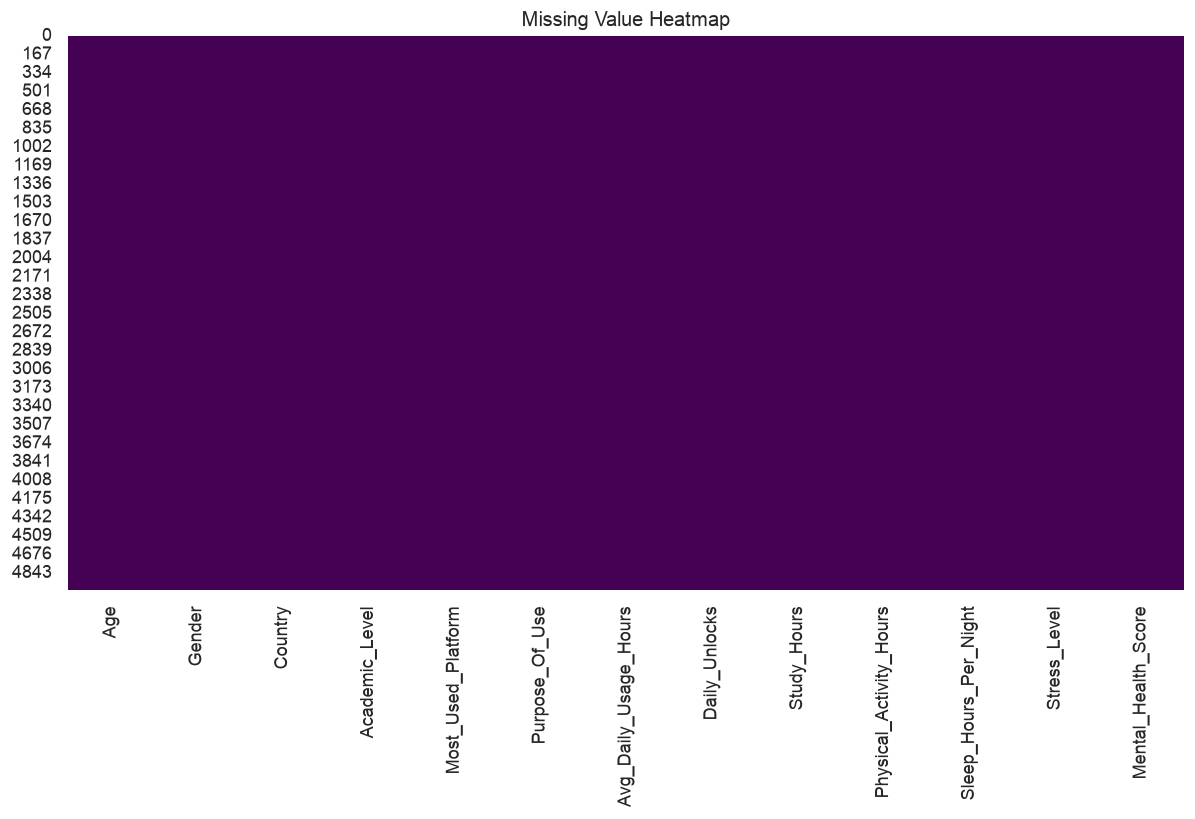

In [24]:
# ==============================================================================
# MISSING VALUE HEATMAP
# ==============================================================================

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

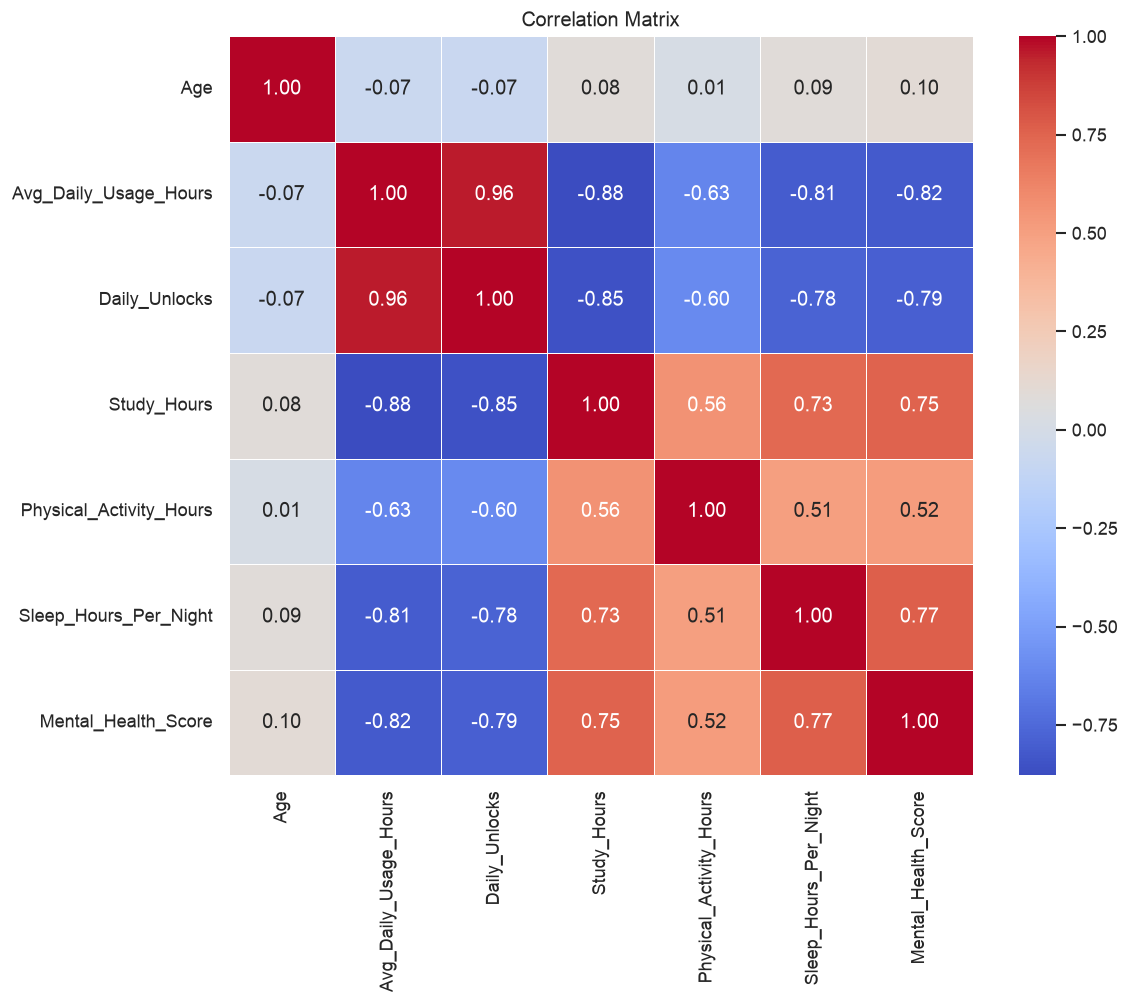

In [25]:
# ==============================================================================
# CORRELATION MATRIX
# ==============================================================================

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=.5
)

plt.title("Correlation Matrix")

plt.show()

In [26]:
# ==============================================================================
# FEATURE CORRELATION WITH TARGET
# ==============================================================================

corr_target = (
    df.corr(numeric_only=True)["Mental_Health_Score"]
    .sort_values(ascending=False)
)

display(corr_target)

Mental_Health_Score        1.00
Sleep_Hours_Per_Night      0.77
Study_Hours                0.75
Physical_Activity_Hours    0.52
Age                        0.10
Daily_Unlocks             -0.79
Avg_Daily_Usage_Hours     -0.82
Name: Mental_Health_Score, dtype: float64

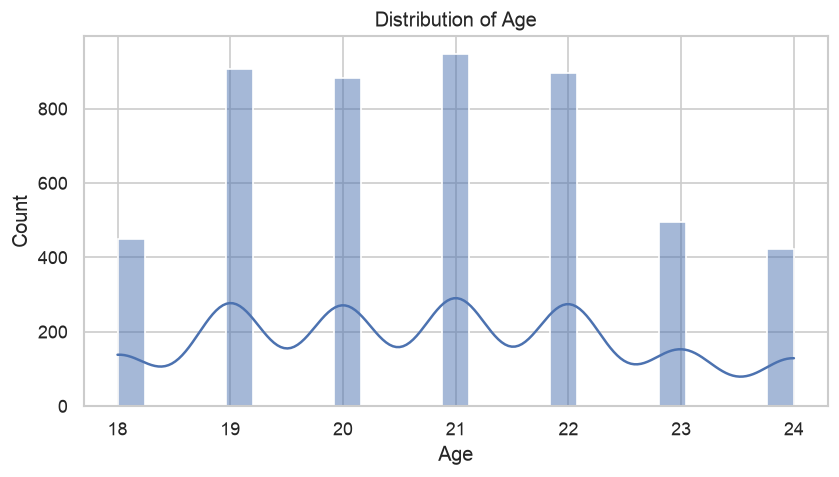

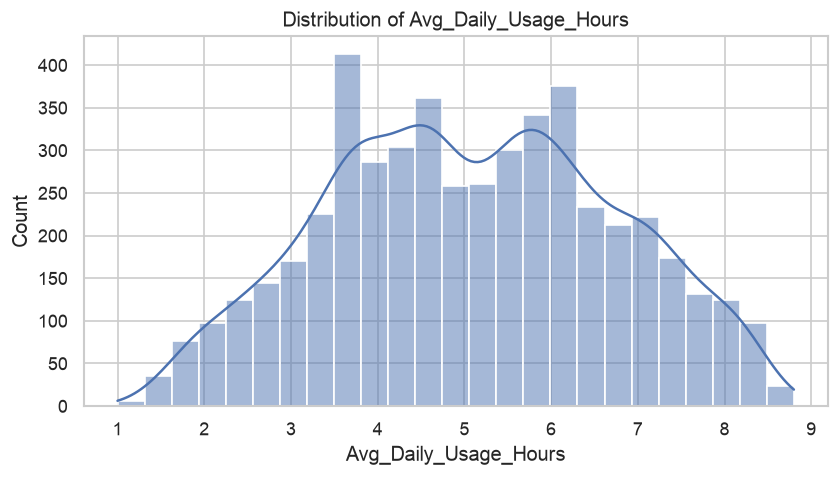

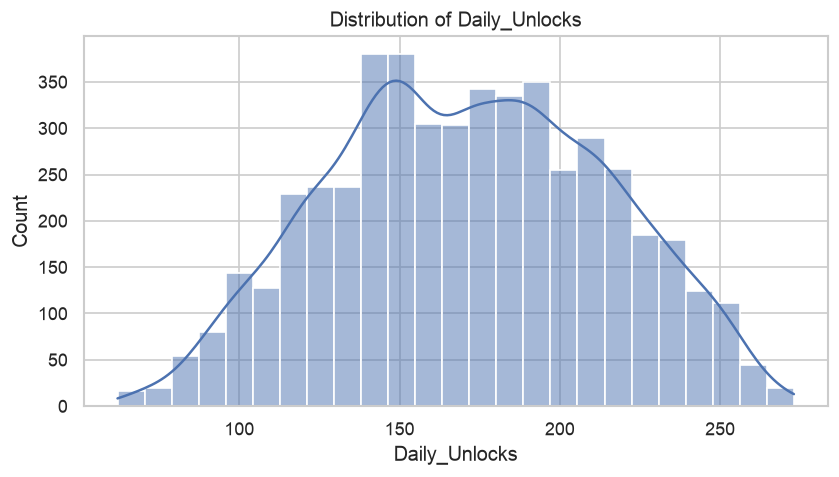

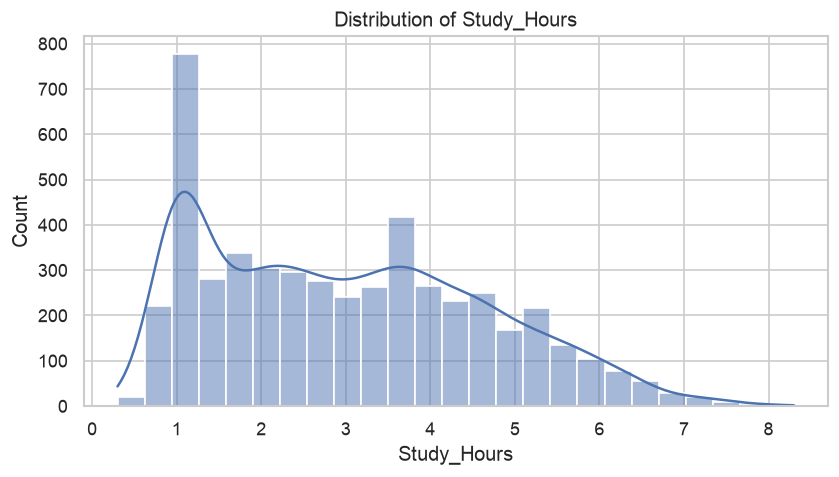

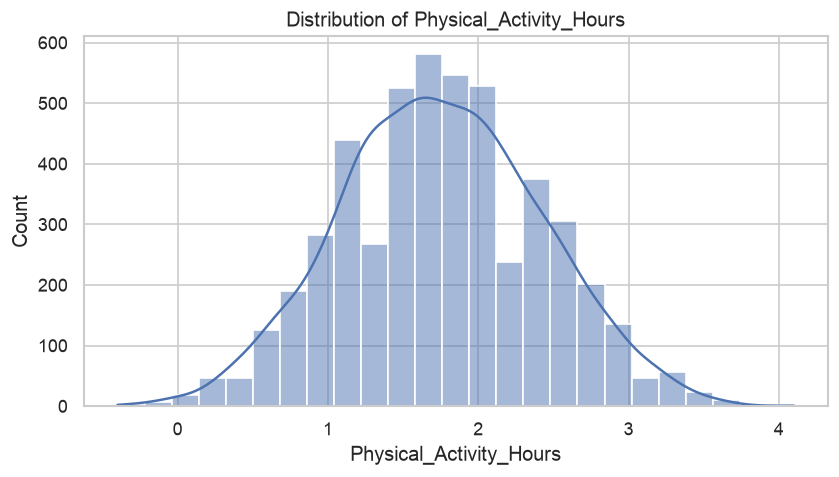

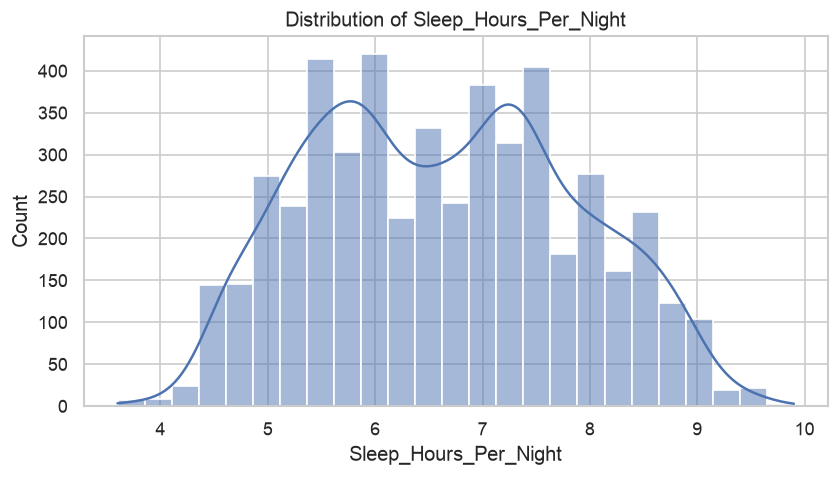

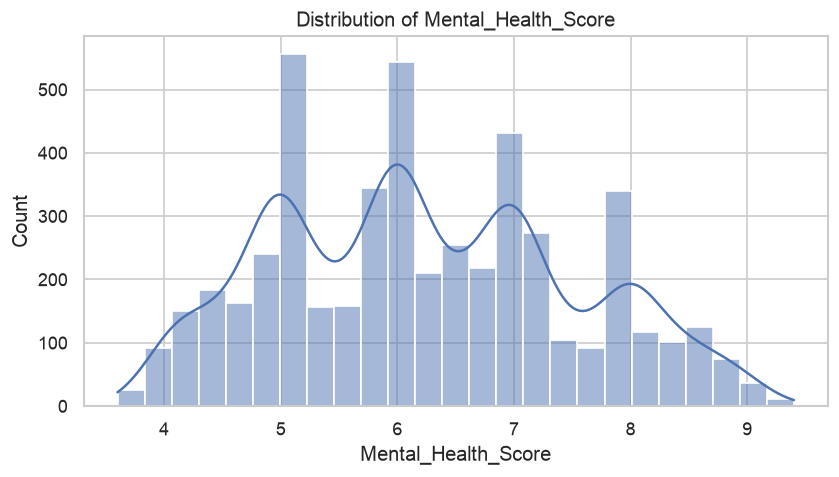

In [27]:
# ==============================================================================
# NUMERICAL FEATURE DISTRIBUTION
# ==============================================================================

numerical_columns = df.select_dtypes(include=np.number).columns

for column in numerical_columns:

    plt.figure(figsize=(8,4))

    sns.histplot(
        data=df,
        x=column,
        kde=True,
        bins=25
    )

    plt.title(f"Distribution of {column}")

    plt.show()

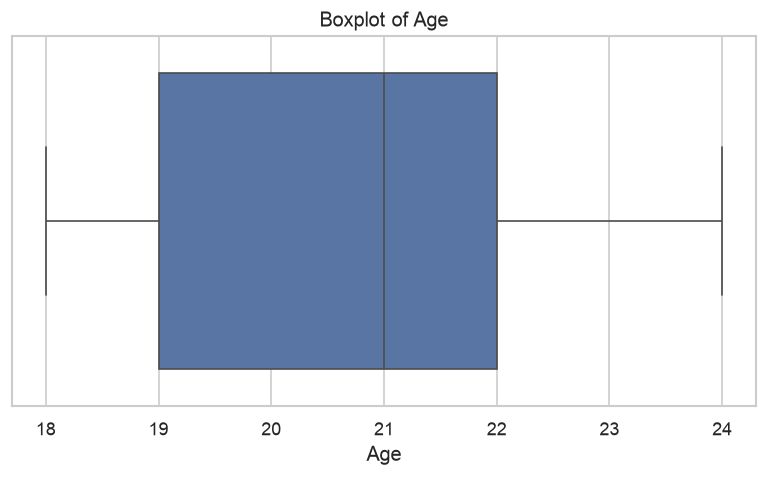

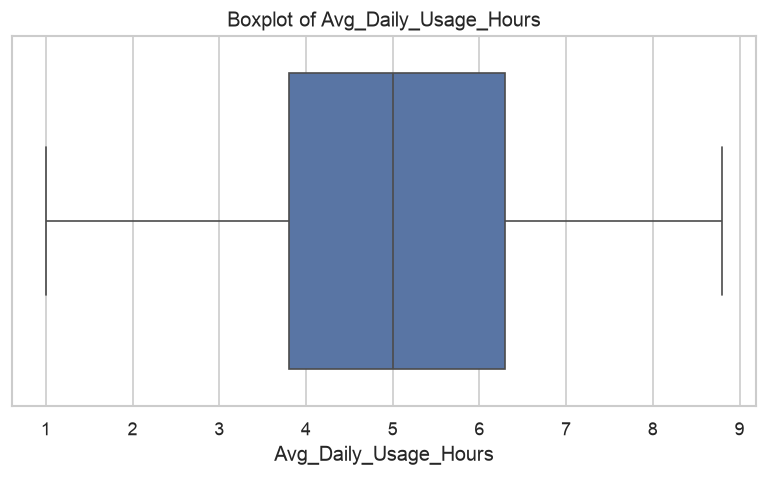

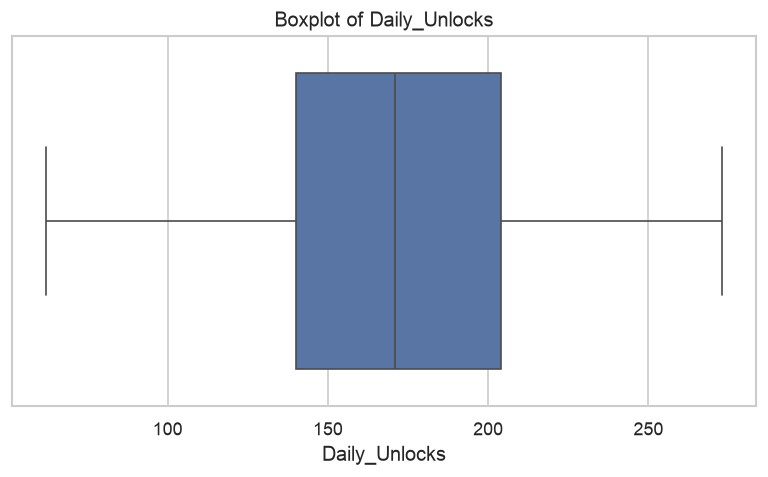

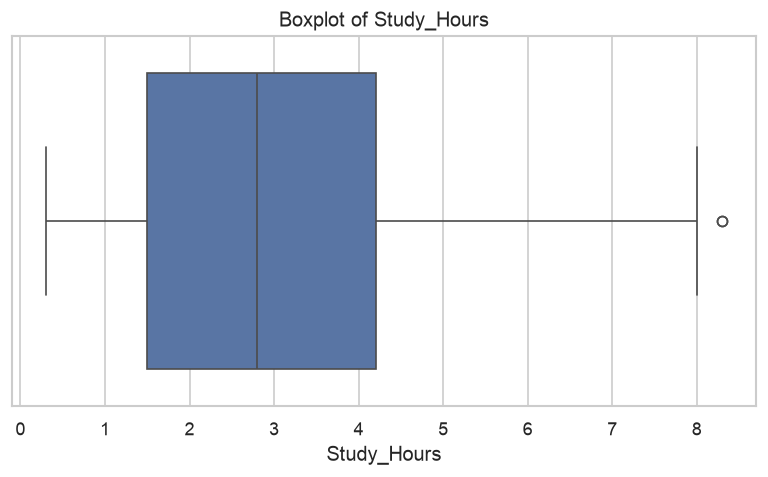

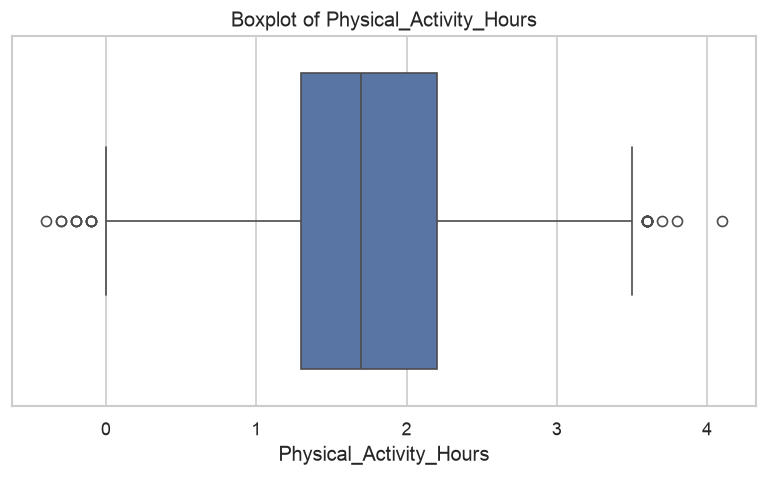

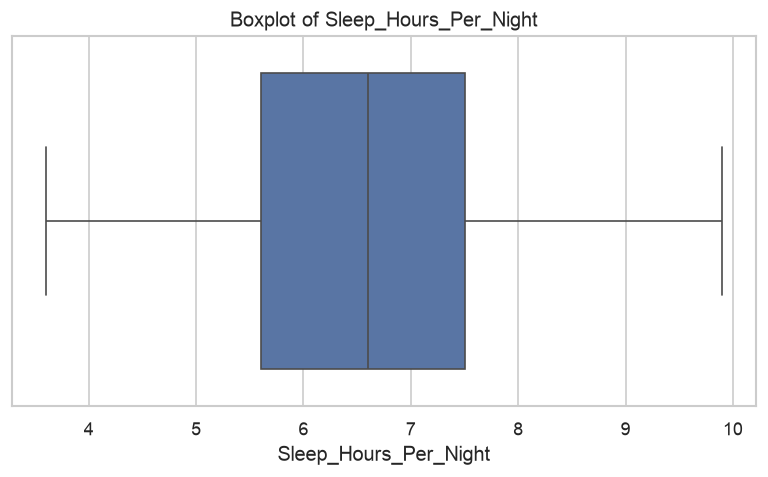

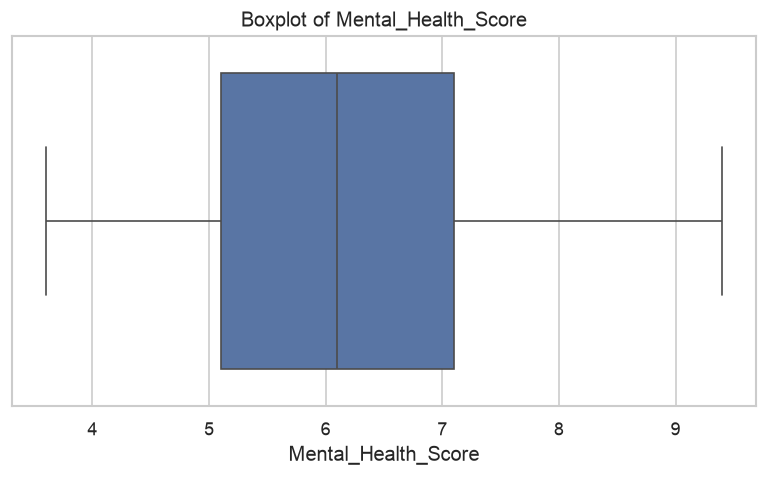

In [28]:
# ==============================================================================
# OUTLIER VISUALIZATION
# ==============================================================================

for column in numerical_columns:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"Boxplot of {column}")

    plt.show()

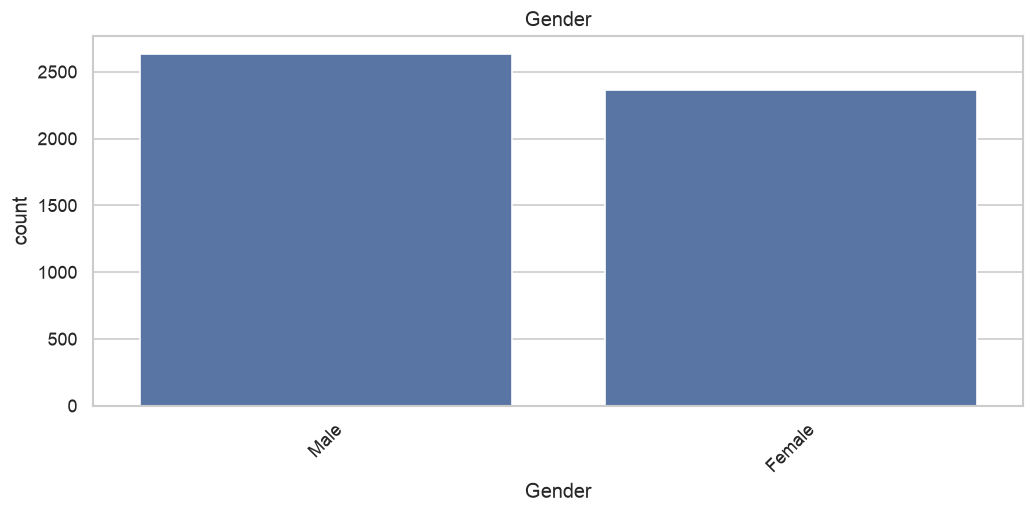

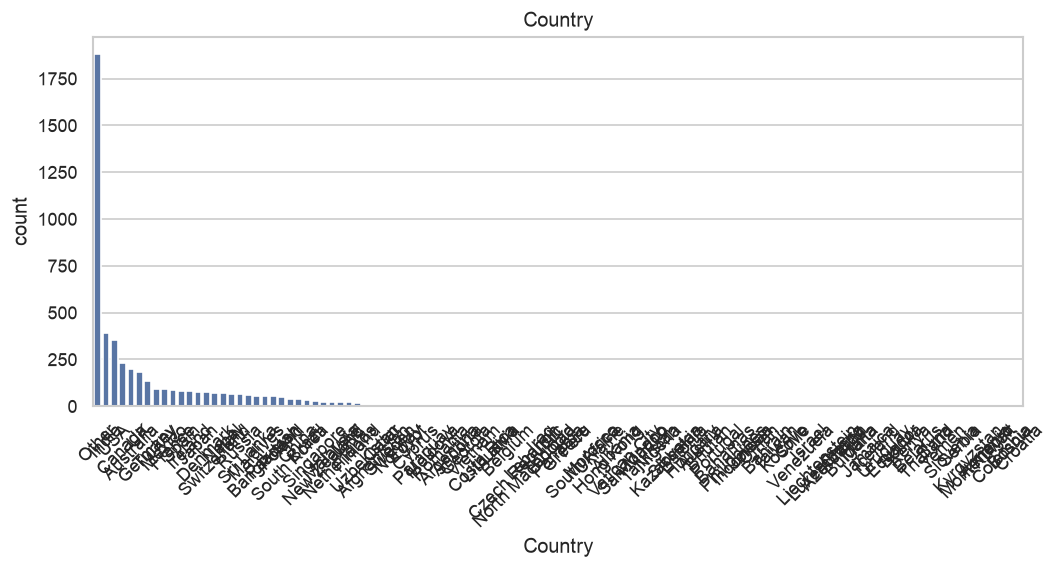

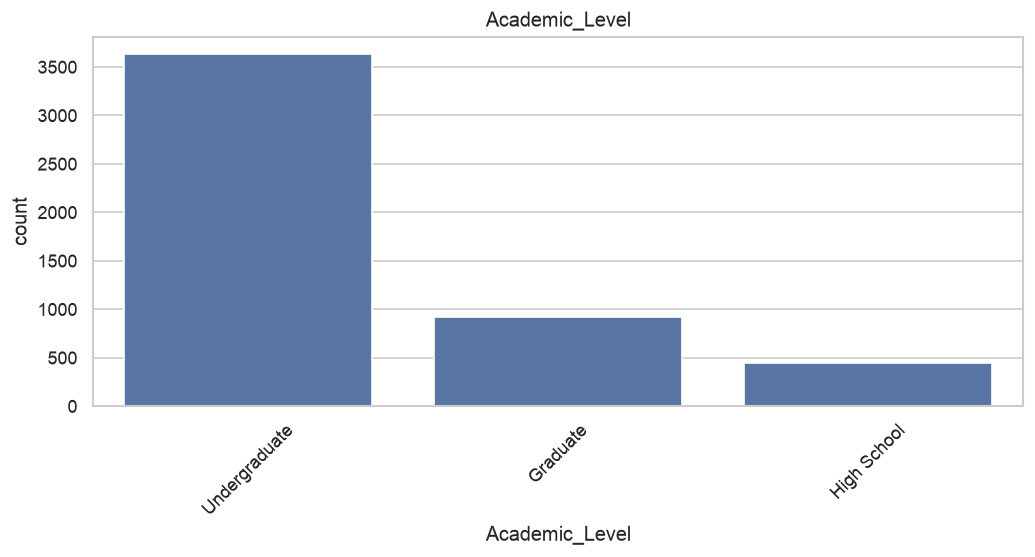

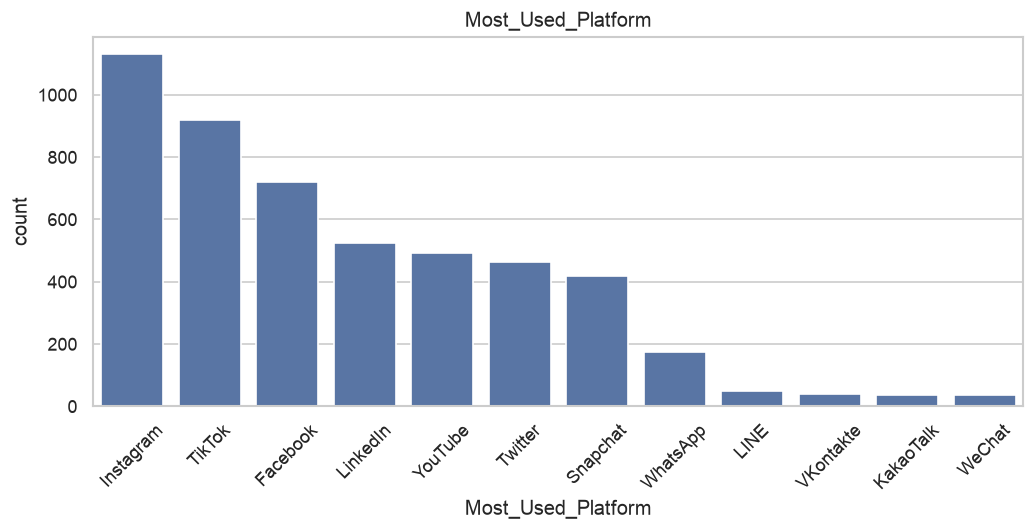

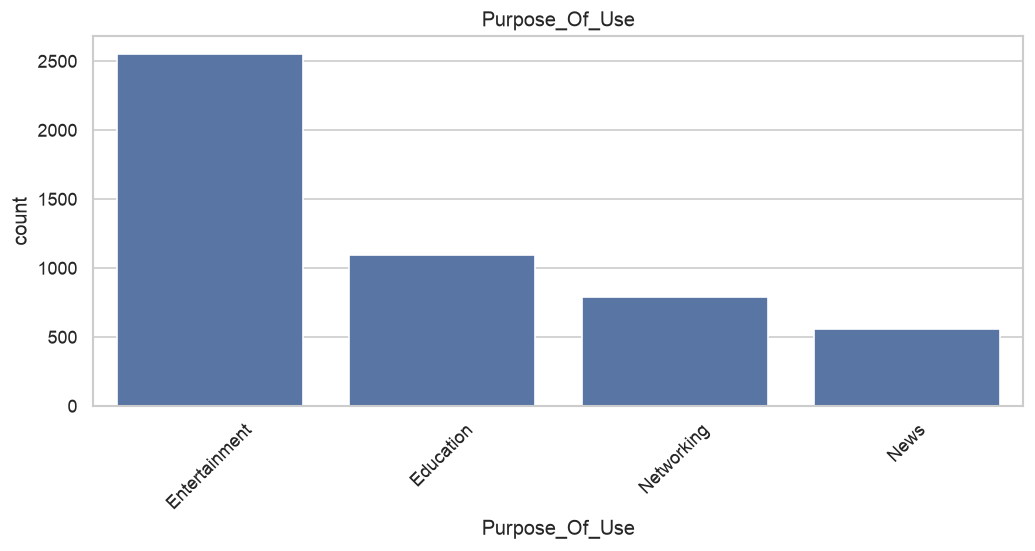

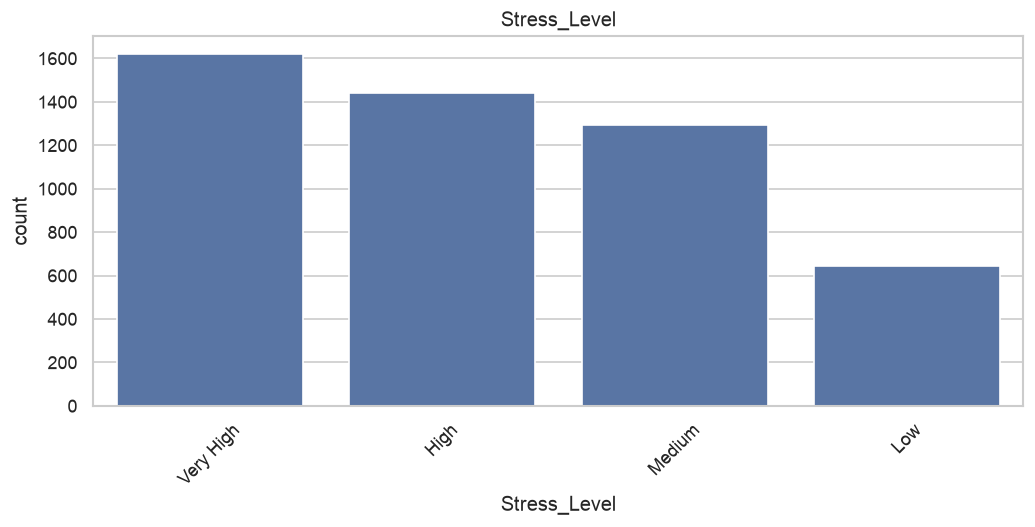

In [29]:
# ==============================================================================
# CATEGORICAL FEATURE DISTRIBUTION
# ==============================================================================

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:

    plt.figure(figsize=(10,4))

    order = df[column].value_counts().index

    sns.countplot(
        data=df,
        x=column,
        order=order
    )

    plt.xticks(rotation=45)

    plt.title(column)

    plt.show()

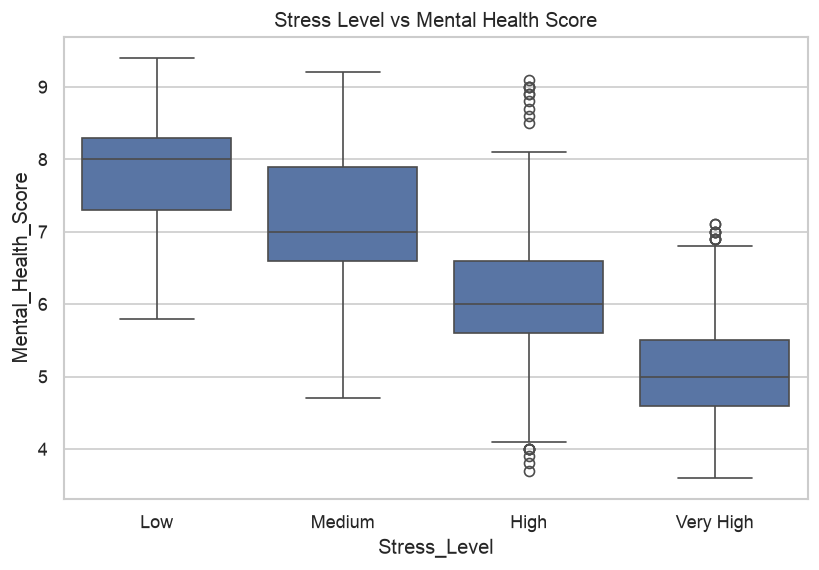

In [30]:
# ==============================================================================
# STRESS LEVEL VS TARGET
# ==============================================================================

order = [
    "Low",
    "Medium",
    "High",
    "Very High"
]

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Stress_Level",
    y="Mental_Health_Score",
    order=order
)

plt.title("Stress Level vs Mental Health Score")

plt.show()

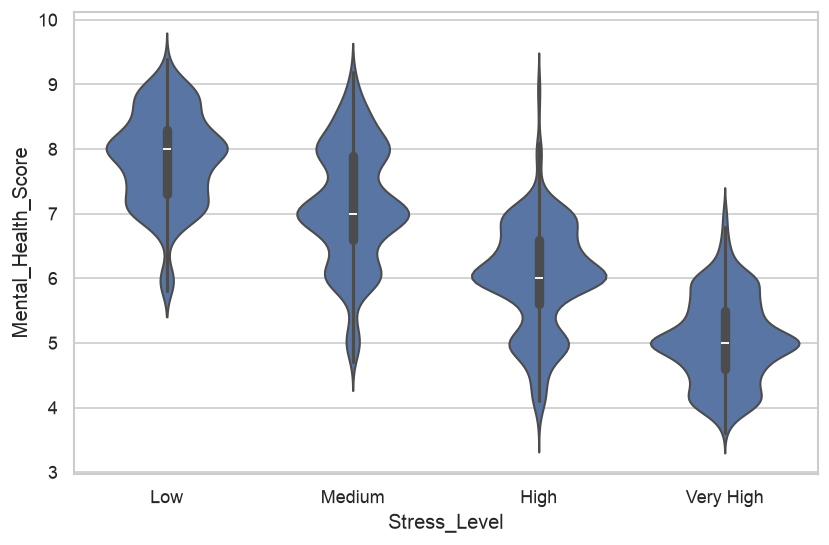

In [31]:
# ==============================================================================
# VIOLIN PLOT
# ==============================================================================

plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="Stress_Level",
    y="Mental_Health_Score",
    order=order
)

plt.show()

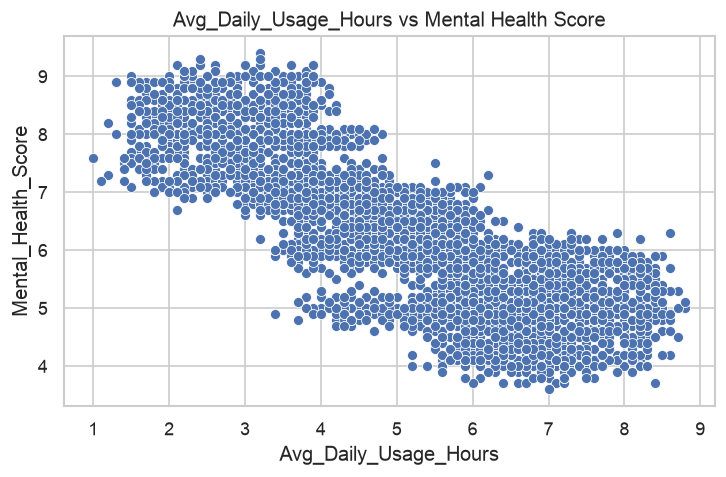

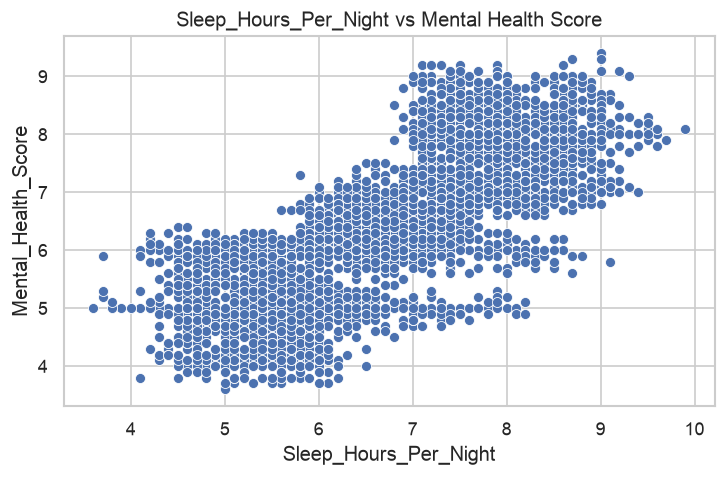

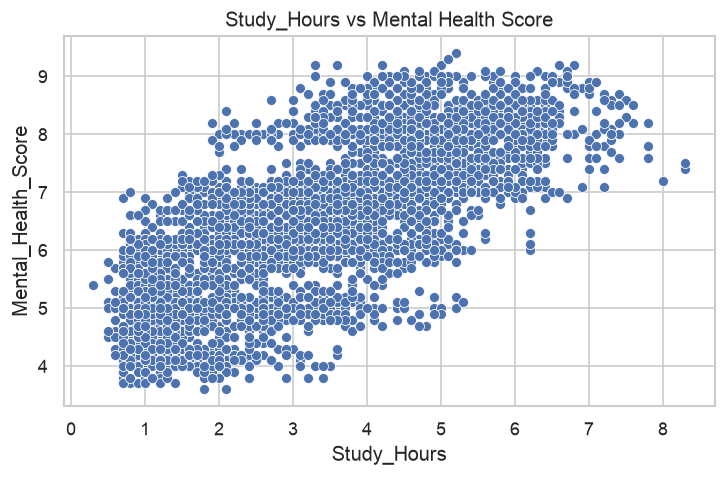

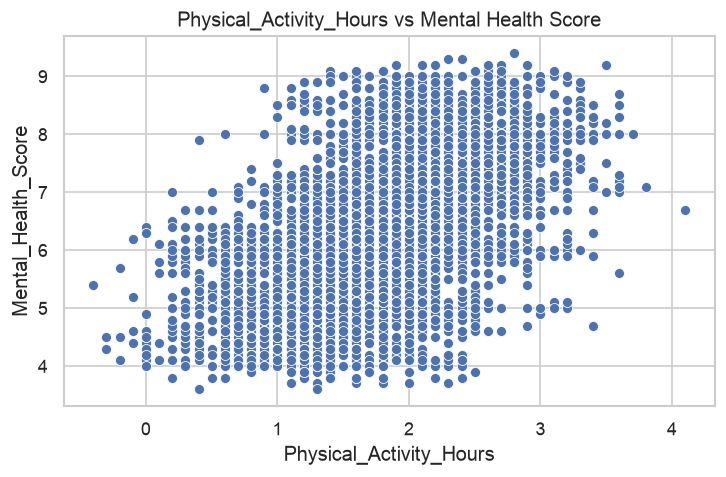

In [32]:
# ==============================================================================
# NUMERICAL FEATURES VS TARGET
# ==============================================================================

important_features = [

    "Avg_Daily_Usage_Hours",

    "Sleep_Hours_Per_Night",

    "Study_Hours",

    "Physical_Activity_Hours"

]

for column in important_features:

    plt.figure(figsize=(7,4))

    sns.scatterplot(
        data=df,
        x=column,
        y="Mental_Health_Score"
    )

    plt.title(f"{column} vs Mental Health Score")

    plt.show()

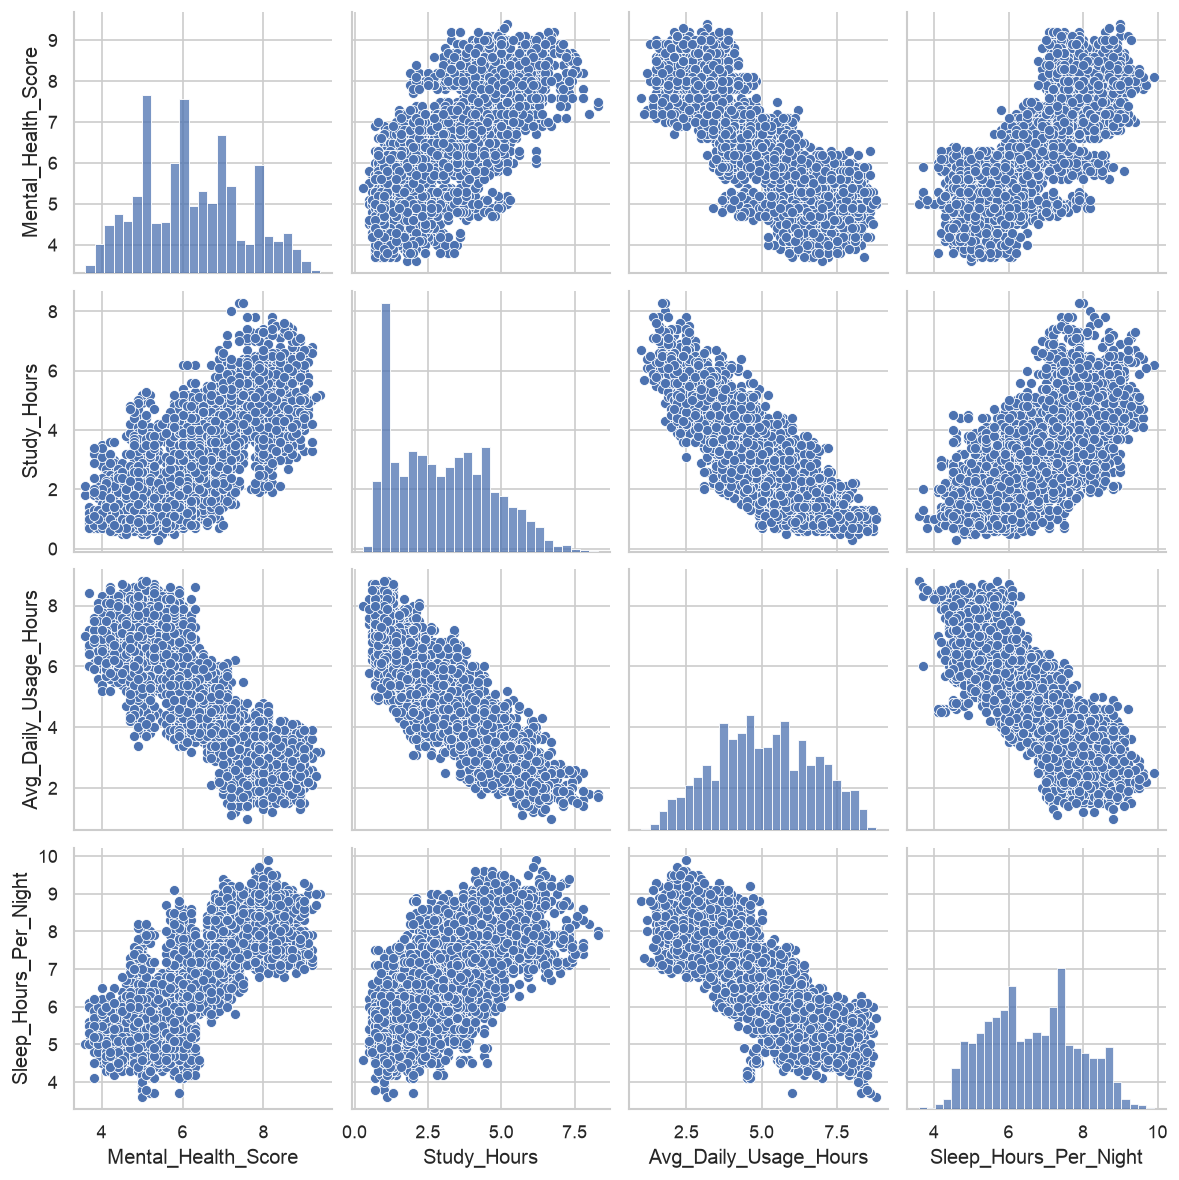

In [33]:
# ==============================================================================
# PAIRPLOT
# ==============================================================================

pair_columns = [

    "Mental_Health_Score",

    "Study_Hours",

    "Avg_Daily_Usage_Hours",

    "Sleep_Hours_Per_Night"

]

sns.pairplot(df[pair_columns])

plt.show()

In [38]:
# ==============================================================================
# OUTLIER ANALYSIS
# ==============================================================================

# Select only numerical columns
numerical_columns = df.select_dtypes(include=np.number)

# Calculate Quartiles
Q1 = numerical_columns.quantile(0.25)
Q3 = numerical_columns.quantile(0.75)

# Calculate Interquartile Range (IQR)
IQR = Q3 - Q1

# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = (
    (numerical_columns < lower_bound) |
    (numerical_columns > upper_bound)
)

# Count outliers
outlier_count = outliers.sum()

# Calculate percentage of outliers
outlier_percent = (outlier_count / len(df)) * 100

# Create summary table
outlier_summary = pd.DataFrame({
    "Outlier Count": outlier_count,
    "Outlier Percentage (%)": outlier_percent.round(2)
})

print("Outlier Summary")
display(outlier_summary)

Outlier Summary


,Outlier Count,Outlier Percentage (%)
Age,0,0.00
Avg_Daily_Usage_Hours,0,0.00
Daily_Unlocks,0,0.00
Study_Hours,2,0.04
Physical_Activity_Hours,22,0.44
Sleep_Hours_Per_Night,0,0.00
Mental_Health_Score,0,0.00


In [35]:
# ==============================================================================
# SKEWNESS ANALYSIS
# ==============================================================================

skewness = df.select_dtypes(include=np.number).skew()

display(skewness.sort_values())

Daily_Unlocks             0.00
Avg_Daily_Usage_Hours     0.01
Physical_Activity_Hours   0.04
Sleep_Hours_Per_Night     0.12
Age                       0.16
Mental_Health_Score       0.21
Study_Hours               0.44
dtype: float64

In [36]:
# ==============================================================================
# EDA SUMMARY
# ==============================================================================

print("="*70)

print("EDA COMPLETED SUCCESSFULLY")

print("="*70)

print(f"Total Numerical Features   : {len(numerical_columns)}")

print(f"Total Categorical Features : {len(categorical_columns)}")

print(f"Duplicate Records          : {df.duplicated().sum()}")

print(f"Missing Values             : {df.isnull().sum().sum()}")

print("="*70)

EDA COMPLETED SUCCESSFULLY
Total Numerical Features   : 7
Total Categorical Features : 6
Duplicate Records          : 2
Missing Values             : 0


In [39]:
# ==============================================================================
# CREATE WORKING COPY
# ==============================================================================

# Keep the original dataset unchanged
df_clean = df.copy()

print("Working copy created successfully.")

Working copy created successfully.


In [40]:
# ==============================================================================
# REMOVE DUPLICATES
# ==============================================================================

duplicates_before = df_clean.duplicated().sum()

print(f"Duplicate Rows Before Cleaning : {duplicates_before}")

df_clean = df_clean.drop_duplicates()

duplicates_after = df_clean.duplicated().sum()

print(f"Duplicate Rows After Cleaning  : {duplicates_after}")

print(f"Rows Removed                  : {duplicates_before - duplicates_after}")

Duplicate Rows Before Cleaning : 2
Duplicate Rows After Cleaning  : 0
Rows Removed                  : 2


In [41]:
# ==============================================================================
# HANDLE MISSING VALUES
# ==============================================================================

missing = df_clean.isnull().sum()

if missing.sum() == 0:
    print("No missing values found.")
else:
    print(missing)

No missing values found.


In [42]:
# ==============================================================================
# DATA VALIDATION
# ==============================================================================

# Physical activity cannot be negative
df_clean["Physical_Activity_Hours"] = (
    df_clean["Physical_Activity_Hours"]
    .clip(lower=0)
)

# Sleep hours cannot be negative
df_clean["Sleep_Hours_Per_Night"] = (
    df_clean["Sleep_Hours_Per_Night"]
    .clip(lower=0)
)

# Daily usage cannot be negative
df_clean["Avg_Daily_Usage_Hours"] = (
    df_clean["Avg_Daily_Usage_Hours"]
    .clip(lower=0)
)

print("Negative values corrected.")

Negative values corrected.


In [43]:
# ==============================================================================
# OUTLIER DETECTION
# ==============================================================================

numerical_columns = df_clean.select_dtypes(include=np.number)

Q1 = numerical_columns.quantile(0.25)
Q3 = numerical_columns.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = (
    (numerical_columns < lower) |
    (numerical_columns > upper)
)

summary = pd.DataFrame({

    "Outliers": outliers.sum(),

    "Percentage": (
        outliers.sum()/len(df_clean)*100
    ).round(2)

})

display(summary)

,Outliers,Percentage
Age,0,0.00
Avg_Daily_Usage_Hours,0,0.00
Daily_Unlocks,0,0.00
Study_Hours,2,0.04
Physical_Activity_Hours,12,0.24
Sleep_Hours_Per_Night,0,0.00
Mental_Health_Score,0,0.00


In [44]:
# ==============================================================================
# SKEWNESS ANALYSIS
# ==============================================================================

skewness = (
    df_clean
    .select_dtypes(include=np.number)
    .skew()
    .sort_values(ascending=False)
)

display(skewness)

Study_Hours               0.44
Mental_Health_Score       0.21
Age                       0.16
Sleep_Hours_Per_Night     0.12
Physical_Activity_Hours   0.05
Avg_Daily_Usage_Hours     0.01
Daily_Unlocks             0.00
dtype: float64

In [45]:
# ==============================================================================
# COUNTRY GROUPING
# ==============================================================================

TOP_COUNTRIES = 10

top_countries = (
    df_clean["Country"]
    .value_counts()
    .nlargest(TOP_COUNTRIES)
    .index
)

df_clean["Grouped_country"] = np.where(
    df_clean["Country"].isin(top_countries),
    df_clean["Country"],
    "Other"
)

print(df_clean["Grouped_country"].value_counts())

Grouped_country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64


In [46]:
# ==============================================================================
# FEATURE ENGINEERING
# ==============================================================================

# Total productive hours
df_clean["Productive_Hours"] = (
    df_clean["Study_Hours"] +
    df_clean["Physical_Activity_Hours"]
)

# Lifestyle balance
df_clean["Lifestyle_Balance"] = (
    df_clean["Sleep_Hours_Per_Night"] -
    df_clean["Avg_Daily_Usage_Hours"]
)

print("New Features Added")

display(
    df_clean[
        [
            "Productive_Hours",
            "Lifestyle_Balance"
        ]
    ].head()
)

New Features Added


,Productive_Hours,Lifestyle_Balance
0,6.70,2.70
1,9.40,7.00
2,5.80,2.10
3,2.70,-1.60
4,2.10,-2.50


In [47]:
# ==============================================================================
# FINAL DATASET CHECK
# ==============================================================================

print(df_clean.info())

display(df_clean.head())

<class 'pandas.core.frame.DataFrame'>
Index: 4998 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4998 non-null   int64  
 1   Gender                   4998 non-null   object 
 2   Country                  4998 non-null   object 
 3   Academic_Level           4998 non-null   object 
 4   Most_Used_Platform       4998 non-null   object 
 5   Purpose_Of_Use           4998 non-null   object 
 6   Avg_Daily_Usage_Hours    4998 non-null   float64
 7   Daily_Unlocks            4998 non-null   int64  
 8   Study_Hours              4998 non-null   float64
 9   Physical_Activity_Hours  4998 non-null   float64
 10  Sleep_Hours_Per_Night    4998 non-null   float64
 11  Stress_Level             4998 non-null   object 
 12  Mental_Health_Score      4998 non-null   float64
 13  Grouped_country          4998 non-null   object 
 14  Productive_Hours         4998

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,Grouped_country,Productive_Hours,Lifestyle_Balance
0,21,Male,Other,Undergraduate,Facebook,Networking,4.00,134,4.50,2.20,6.70,Medium,6.80,Other,6.70,2.70
1,23,Female,Other,Graduate,LinkedIn,Education,1.60,73,7.00,2.40,8.60,Low,7.60,Other,9.40,7.00
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.60,166,4.00,1.80,6.70,Medium,7.00,Canada,5.80,2.10
3,18,Male,Other,High School,Snapchat,Entertainment,7.00,220,1.00,1.70,5.40,Very High,5.30,Other,2.70,-1.60
4,24,Female,Other,Graduate,Facebook,Networking,7.50,237,1.00,1.10,5.00,Very High,4.40,Other,2.10,-2.50


In [48]:
df_clean

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,Grouped_country,Productive_Hours,Lifestyle_Balance
0,21,Male,Other,Undergraduate,Facebook,Networking,4.00,134,4.50,2.20,6.70,Medium,6.80,Other,6.70,2.70
1,23,Female,Other,Graduate,LinkedIn,Education,1.60,73,7.00,2.40,8.60,Low,7.60,Other,9.40,7.00
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.60,166,4.00,1.80,6.70,Medium,7.00,Canada,5.80,2.10
3,18,Male,Other,High School,Snapchat,Entertainment,7.00,220,1.00,1.70,5.40,Very High,5.30,Other,2.70,-1.60
4,24,Female,Other,Graduate,Facebook,Networking,7.50,237,1.00,1.10,5.00,Very High,4.40,Other,2.10,-2.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.90,89,6.10,2.20,7.90,Low,7.90,Other,8.30,6.00
4996,18,Female,Other,High School,YouTube,Education,6.60,216,2.30,1.80,6.00,Very High,4.70,Other,4.10,-0.60
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.80,151,5.40,1.40,7.50,Medium,7.00,India,6.80,3.70
4998,18,Male,Other,High School,Instagram,Entertainment,3.80,119,4.00,1.50,6.40,Medium,6.70,Other,5.50,2.60


In [50]:
# ==============================================================================
# FEATURE CONFIGURATION
# ==============================================================================

# -----------------------------
# Target Column
# -----------------------------
TARGET = "Mental_Health_Score"

# -----------------------------
# Skewed Numerical Features
# -----------------------------
SKEWED_FEATURES = [
    "Study_Hours"
]

# -----------------------------
# Normal Numerical Features
# -----------------------------
NUMERICAL_FEATURES = [
    "Age",
    "Avg_Daily_Usage_Hours",
    "Daily_Unlocks",
    "Physical_Activity_Hours",
    "Sleep_Hours_Per_Night",
    "Productive_Hours",
    "Lifestyle_Balance"
]

# -----------------------------
# Ordinal Features
# -----------------------------
ORDINAL_FEATURES = [
    "Stress_Level"
]

# -----------------------------
# Nominal Features
# -----------------------------
NOMINAL_FEATURES = [
    "Gender",
    "Academic_Level",
    "Most_Used_Platform",
    "Purpose_Of_Use",
    "Grouped_country"
]

# -----------------------------
# Complete Feature List
# -----------------------------
FEATURE_COLUMNS = (
    SKEWED_FEATURES
    + NUMERICAL_FEATURES
    + ORDINAL_FEATURES
    + NOMINAL_FEATURES
)

print("Feature configuration completed.")

Feature configuration completed.


In [51]:
# ==============================================================================
# INPUT AND TARGET
# ==============================================================================

X = df_clean[FEATURE_COLUMNS]

y = df_clean[TARGET]

print("Input Shape :", X.shape)
print("Target Shape:", y.shape)

Input Shape : (4998, 14)
Target Shape: (4998,)


In [52]:
# ==============================================================================
# TRAIN TEST SPLIT
# ==============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print()

print("="*60)

print("Training Samples :", X_train.shape[0])

print("Testing Samples  :", X_test.shape[0])

print("="*60)


Training Samples : 3998
Testing Samples  : 1000


In [53]:
# ==============================================================================
# PREPROCESSING LIBRARIES
# ==============================================================================

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    FunctionTransformer,
    StandardScaler,
    OrdinalEncoder,
    OneHotEncoder
)

In [62]:
# ==============================================================================
# SKEWED FEATURE PIPELINE
# ==============================================================================

skewed_pipeline = Pipeline(
    steps=[
        (
            "log_transform",
            FunctionTransformer(
                np.log1p,
                validate=False,
                feature_names_out="one-to-one"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [63]:
# ==============================================================================
# NUMERICAL PIPELINE
# ==============================================================================

numerical_pipeline = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [64]:
# ==============================================================================
# ORDINAL PIPELINE
# ==============================================================================

ordinal_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OrdinalEncoder(
                categories=[
                    [
                        "Low",
                        "Medium",
                        "High",
                        "Very High"
                    ]
                ]
            )
        )
    ]
)

In [65]:
# ==============================================================================
# NOMINAL PIPELINE
# ==============================================================================

nominal_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [66]:
# ==============================================================================
# COLUMN TRANSFORMER
# ==============================================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "Skewed",
            skewed_pipeline,
            SKEWED_FEATURES
        ),

        (
            "Numeric",
            numerical_pipeline,
            NUMERICAL_FEATURES
        ),

        (
            "Ordinal",
            ordinal_pipeline,
            ORDINAL_FEATURES
        ),

        (
            "Nominal",
            nominal_pipeline,
            NOMINAL_FEATURES
        )

    ],

    remainder="drop"

)

In [67]:
# ==============================================================================
# VERIFY PREPROCESSOR
# ==============================================================================

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print()

print("="*60)

print("Original Training Shape")

print(X_train.shape)

print()

print("Processed Training Shape")

print(X_train_processed.shape)

print()

print("Original Testing Shape")

print(X_test.shape)

print()

print("Processed Testing Shape")

print(X_test_processed.shape)

print("="*60)


Original Training Shape
(3998, 14)

Processed Training Shape
(3998, 40)

Original Testing Shape
(1000, 14)

Processed Testing Shape
(1000, 40)


In [70]:
# Fit the preprocessor first
preprocessor.fit(X_train)

# Get one-hot encoded feature names
ohe = preprocessor.named_transformers_["Nominal"] \
                  .named_steps["encoder"]

encoded_names = ohe.get_feature_names_out(NOMINAL_FEATURES)

feature_names = (
    SKEWED_FEATURES +
    NUMERICAL_FEATURES +
    ORDINAL_FEATURES +
    list(encoded_names)
)

print(f"Total Features: {len(feature_names)}")

display(feature_names)

Total Features: 40


['Study_Hours',
 'Age',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Productive_Hours',
 'Lifestyle_Balance',
 'Stress_Level',
 'Gender_Female',
 'Gender_Male',
 'Academic_Level_Graduate',
 'Academic_Level_High School',
 'Academic_Level_Undergraduate',
 'Most_Used_Platform_Facebook',
 'Most_Used_Platform_Instagram',
 'Most_Used_Platform_KakaoTalk',
 'Most_Used_Platform_LINE',
 'Most_Used_Platform_LinkedIn',
 'Most_Used_Platform_Snapchat',
 'Most_Used_Platform_TikTok',
 'Most_Used_Platform_Twitter',
 'Most_Used_Platform_VKontakte',
 'Most_Used_Platform_WeChat',
 'Most_Used_Platform_WhatsApp',
 'Most_Used_Platform_YouTube',
 'Purpose_Of_Use_Education',
 'Purpose_Of_Use_Entertainment',
 'Purpose_Of_Use_Networking',
 'Purpose_Of_Use_News',
 'Grouped_country_Australia',
 'Grouped_country_Canada',
 'Grouped_country_France',
 'Grouped_country_Germany',
 'Grouped_country_India',
 'Grouped_country_Mexico',
 'Grouped_country_Other',
 'Groupe

In [71]:
# ==============================================================================
# TRANSFORMED DATASET
# ==============================================================================

processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

display(processed_df.head())

,Study_Hours,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Physical_Activity_Hours,Sleep_Hours_Per_Night,Productive_Hours,Lifestyle_Balance,Stress_Level,Gender_Female,Gender_Male,Academic_Level_Graduate,Academic_Level_High School,Academic_Level_Undergraduate,Most_Used_Platform_Facebook,Most_Used_Platform_Instagram,Most_Used_Platform_KakaoTalk,Most_Used_Platform_LINE,Most_Used_Platform_LinkedIn,Most_Used_Platform_Snapchat,Most_Used_Platform_TikTok,Most_Used_Platform_Twitter,Most_Used_Platform_VKontakte,Most_Used_Platform_WeChat,Most_Used_Platform_WhatsApp,Most_Used_Platform_YouTube,Purpose_Of_Use_Education,Purpose_Of_Use_Entertainment,Purpose_Of_Use_Networking,Purpose_Of_Use_News,Grouped_country_Australia,Grouped_country_Canada,Grouped_country_France,Grouped_country_Germany,Grouped_country_India,Grouped_country_Mexico,Grouped_country_Other,Grouped_country_Turkey,Grouped_country_UK,Grouped_country_USA
0,0.38,-1.05,0.01,0.22,-0.52,0.38,-0.02,0.16,1.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
1,1.49,-1.62,-2.12,-1.73,2.78,0.87,2.29,1.67,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
2,-0.11,-0.47,-0.66,-0.06,-0.07,0.63,-0.26,0.68,2.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
3,0.08,0.10,0.44,0.76,-0.97,0.05,-0.41,-0.24,2.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,-2.11,1.25,1.41,1.42,-2.63,-1.34,-2.05,-1.45,3.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [72]:
# ==============================================================================
# MACHINE LEARNING LIBRARIES
# ==============================================================================

import time

# Linear Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

# Tree Models
from sklearn.tree import DecisionTreeRegressor

# Ensemble Models
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)

# Evaluation Metrics
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# Cross Validation
from sklearn.model_selection import cross_val_score

print("Machine Learning libraries imported successfully.")

Machine Learning libraries imported successfully.


In [73]:
# ==============================================================================
# MODEL CONFIGURATION
# ==============================================================================

MODELS = {

    "Linear Regression":
        LinearRegression(),

    "Ridge Regression":
        Ridge(random_state=42),

    "Lasso Regression":
        Lasso(random_state=42),

    "Decision Tree":
        DecisionTreeRegressor(random_state=42),

    "Random Forest":
        RandomForestRegressor(random_state=42),

    "Extra Trees":
        ExtraTreesRegressor(random_state=42),

    "Gradient Boosting":
        GradientBoostingRegressor(random_state=42),

    "AdaBoost":
        AdaBoostRegressor(random_state=42)

}

print(f"{len(MODELS)} models loaded successfully.")

8 models loaded successfully.


In [74]:
# ==============================================================================
# RESULTS STORAGE
# ==============================================================================

results = []

print("Results container created.")

Results container created.


In [75]:
# ==============================================================================
# MODEL EVALUATION FUNCTION
# ==============================================================================

def evaluate_model(model, X_train, X_test, y_train, y_test):
    """
    Evaluate a regression model and return important metrics.

    Parameters
    ----------
    model : Pipeline
        Trained machine learning pipeline.

    X_train : DataFrame
    X_test  : DataFrame
    y_train : Series
    y_test  : Series

    Returns
    -------
    Dictionary containing evaluation metrics.
    """

    # -----------------------------
    # Training Prediction
    # -----------------------------
    train_prediction = model.predict(X_train)

    # -----------------------------
    # Testing Prediction
    # -----------------------------
    test_prediction = model.predict(X_test)

    # -----------------------------
    # Metrics
    # -----------------------------
    train_r2 = r2_score(
        y_train,
        train_prediction
    )

    test_r2 = r2_score(
        y_test,
        test_prediction
    )

    mae = mean_absolute_error(
        y_test,
        test_prediction
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_prediction
        )
    )

    return {

        "Training R2": train_r2,

        "Testing R2": test_r2,

        "MAE": mae,

        "RMSE": rmse

    }

In [76]:
# ==============================================================================
# TRAIN MODEL
# ==============================================================================

def train_model(model_name, estimator):
    """
    Train one model using the preprocessing pipeline.
    """

    print("="*60)
    print(f"Training : {model_name}")
    print("="*60)

    # Create Pipeline
    pipeline = Pipeline(

        steps=[

            (
                "preprocessor",
                preprocessor
            ),

            (
                "model",
                estimator
            )

        ]

    )

    # Measure Training Time
    start = time.time()

    pipeline.fit(
        X_train,
        y_train
    )

    end = time.time()

    training_time = end - start

    # Evaluate
    metrics = evaluate_model(
        pipeline,
        X_train,
        X_test,
        y_train,
        y_test
    )

    # Cross Validation
    cv_scores = cross_val_score(

        pipeline,

        X,

        y,

        cv=5,

        scoring="r2",

        n_jobs=-1

    )

    results.append({

        "Model": model_name,

        "Training R2": metrics["Training R2"],

        "Testing R2": metrics["Testing R2"],

        "MAE": metrics["MAE"],

        "RMSE": metrics["RMSE"],

        "CV Mean": cv_scores.mean(),

        "CV Std": cv_scores.std(),

        "Training Time (sec)": training_time

    })

    print("Finished Successfully.\n")

    return pipeline

In [77]:
# ==============================================================================
# VERIFY SETUP
# ==============================================================================

print("="*70)

print("Models Available")

print("="*70)

for model in MODELS.keys():
    print(model)

print()

print(f"Total Models : {len(MODELS)}")

print()

print("Framework Ready!")

print("="*70)

Models Available
Linear Regression
Ridge Regression
Lasso Regression
Decision Tree
Random Forest
Extra Trees
Gradient Boosting
AdaBoost

Total Models : 8

Framework Ready!


In [78]:
# ==============================================================================
# TRAIN ALL MODELS
# ==============================================================================

print("=" * 80)
print("TRAINING ALL MACHINE LEARNING MODELS")
print("=" * 80)

trained_models = {}

for model_name, estimator in MODELS.items():

    pipeline = train_model(
        model_name=model_name,
        estimator=estimator
    )

    trained_models[model_name] = pipeline

print("\n✅ All models trained successfully.")

TRAINING ALL MACHINE LEARNING MODELS
Training : Linear Regression
Finished Successfully.

Training : Ridge Regression
Finished Successfully.

Training : Lasso Regression
Finished Successfully.

Training : Decision Tree
Finished Successfully.

Training : Random Forest
Finished Successfully.

Training : Extra Trees
Finished Successfully.

Training : Gradient Boosting
Finished Successfully.

Training : AdaBoost
Finished Successfully.


✅ All models trained successfully.


In [79]:
# ==============================================================================
# MODEL COMPARISON TABLE
# ==============================================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Testing R2",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,Training R2,Testing R2,MAE,RMSE,CV Mean,CV Std,Training Time (sec)
0,Extra Trees,1.00,0.91,0.27,0.40,0.92,0.00,0.80
1,Random Forest,0.98,0.88,0.34,0.46,0.88,0.01,0.99
2,Gradient Boosting,0.81,0.80,0.46,0.59,0.79,0.02,0.34
3,Decision Tree,1.00,0.77,0.42,0.64,0.76,0.03,0.02
4,AdaBoost,0.75,0.76,0.52,0.65,0.74,0.03,0.15
5,Ridge Regression,0.73,0.74,0.53,0.68,0.72,0.02,0.01
6,Linear Regression,0.73,0.74,0.53,0.68,0.72,0.02,0.02
7,Lasso Regression,0.07,0.07,1.09,1.29,0.08,0.03,0.01


In [80]:
# ==============================================================================
# FORMAT RESULTS
# ==============================================================================

results_df = results_df.round({

    "Training R2":4,

    "Testing R2":4,

    "MAE":4,

    "RMSE":4,

    "CV Mean":4,

    "CV Std":4,

    "Training Time (sec)":3

})

display(results_df)

,Model,Training R2,Testing R2,MAE,RMSE,CV Mean,CV Std,Training Time (sec)
0,Extra Trees,1.00,0.91,0.27,0.40,0.92,0.00,0.80
1,Random Forest,0.98,0.88,0.34,0.46,0.88,0.01,0.99
2,Gradient Boosting,0.81,0.80,0.46,0.59,0.79,0.02,0.34
3,Decision Tree,1.00,0.77,0.42,0.64,0.76,0.03,0.02
4,AdaBoost,0.75,0.76,0.52,0.65,0.74,0.03,0.14
5,Ridge Regression,0.73,0.74,0.53,0.68,0.72,0.02,0.01
6,Linear Regression,0.73,0.74,0.53,0.68,0.72,0.02,0.02
7,Lasso Regression,0.07,0.07,1.09,1.29,0.08,0.03,0.01


In [81]:
# ==============================================================================
# BEST MODEL
# ==============================================================================

best_model_name = results_df.iloc[0]["Model"]

print("="*70)

print(f"🏆 Best Baseline Model : {best_model_name}")

print("="*70)

🏆 Best Baseline Model : Extra Trees


In [82]:
# ==============================================================================
# BEST PIPELINE
# ==============================================================================

best_pipeline = trained_models[best_model_name]

print(best_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('Skewed',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('Numeric',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',


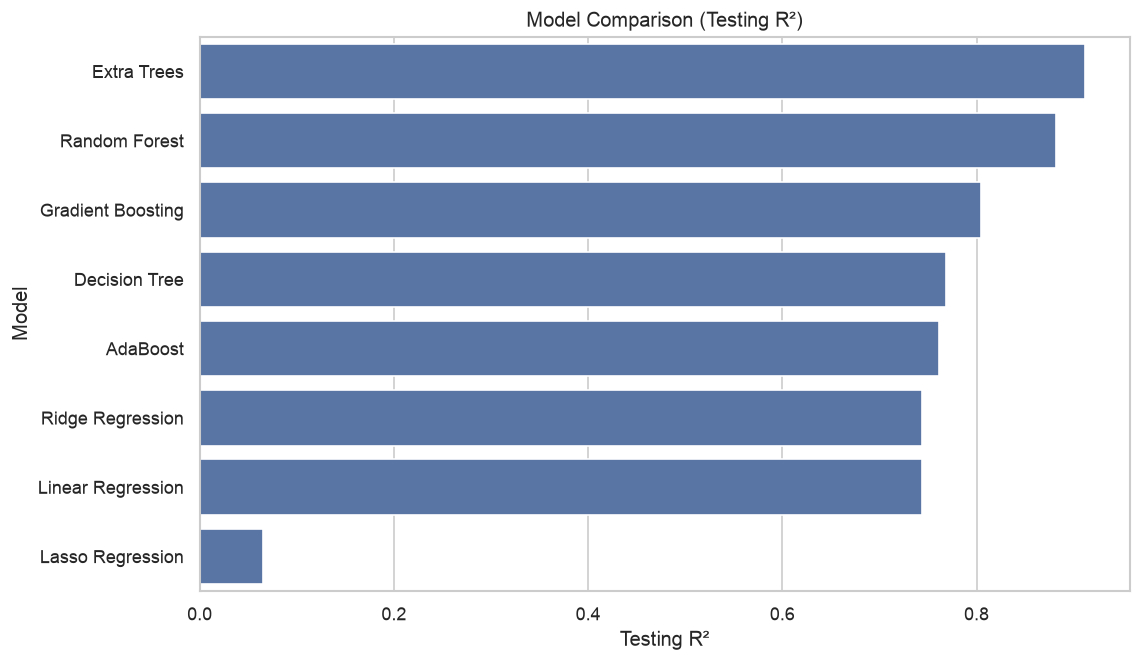

In [83]:
# ==============================================================================
# TESTING R² COMPARISON
# ==============================================================================

plt.figure(figsize=(10,6))

sns.barplot(

    data=results_df,

    x="Testing R2",

    y="Model"

)

plt.title("Model Comparison (Testing R²)")

plt.xlabel("Testing R²")

plt.ylabel("Model")

plt.show()

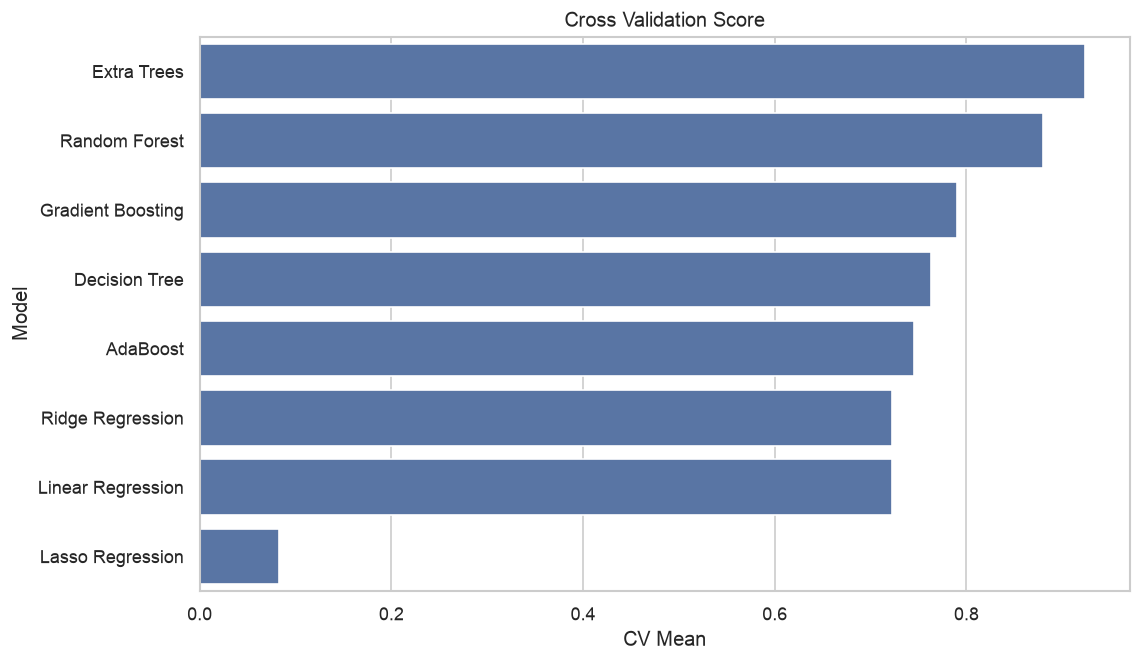

In [84]:
# ==============================================================================
# CROSS VALIDATION SCORE
# ==============================================================================

plt.figure(figsize=(10,6))

sns.barplot(

    data=results_df,

    x="CV Mean",

    y="Model"

)

plt.title("Cross Validation Score")

plt.show()

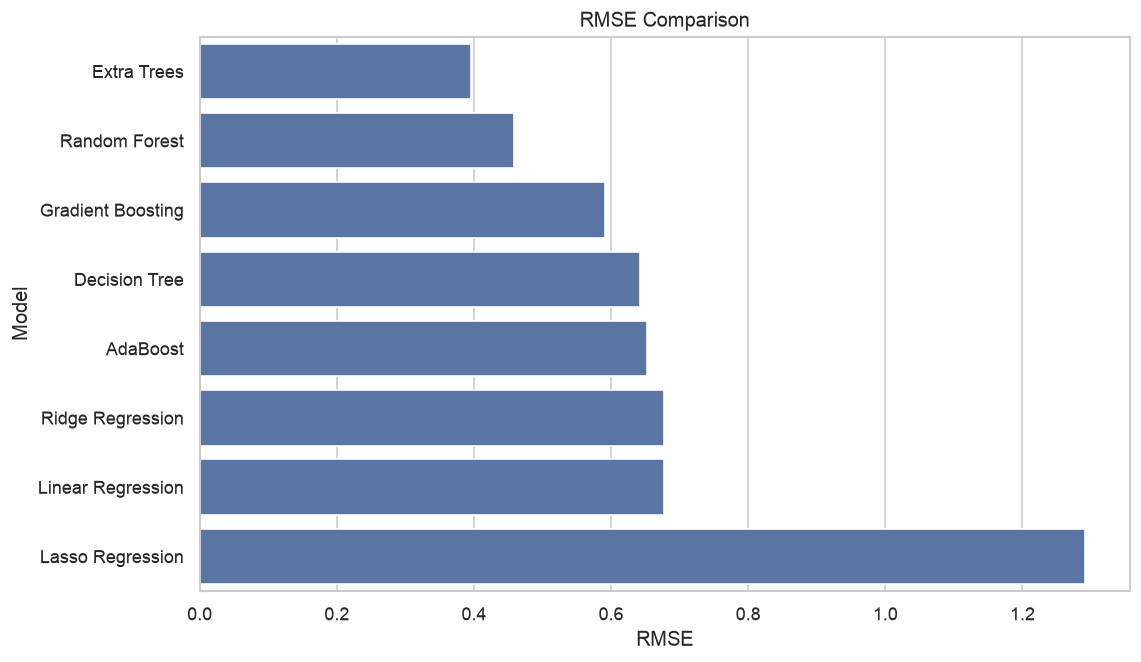

In [85]:
# ==============================================================================
# RMSE COMPARISON
# ==============================================================================

plt.figure(figsize=(10,6))

sns.barplot(

    data=results_df,

    x="RMSE",

    y="Model"

)

plt.title("RMSE Comparison")

plt.show()

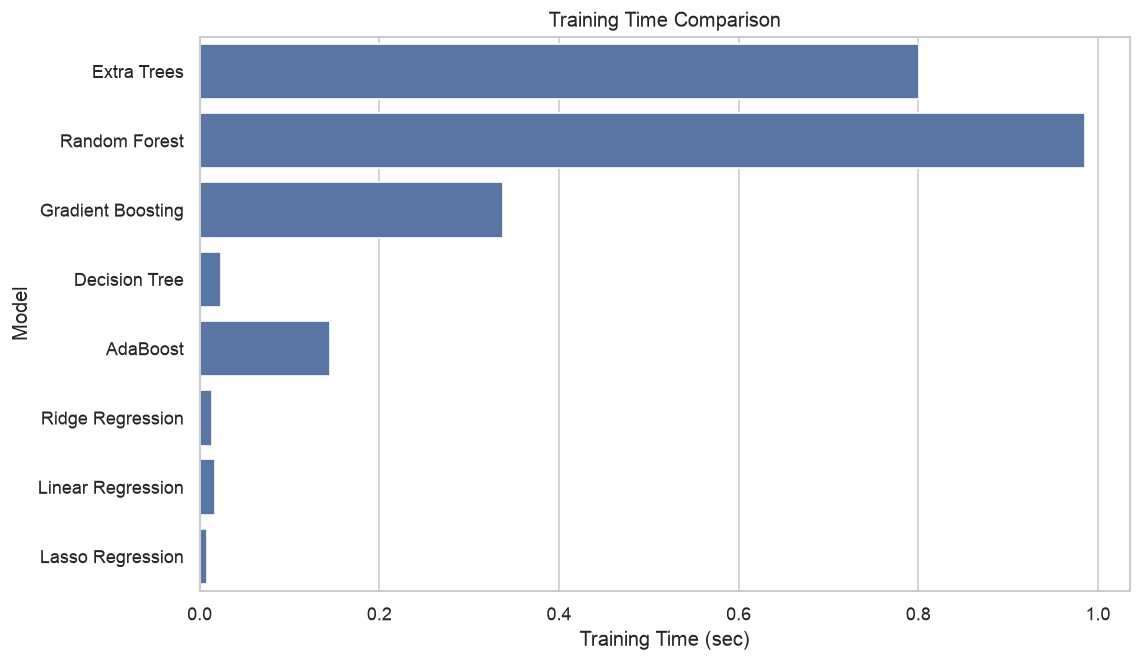

In [86]:
# ==============================================================================
# TRAINING TIME
# ==============================================================================

plt.figure(figsize=(10,6))

sns.barplot(

    data=results_df,

    x="Training Time (sec)",

    y="Model"

)

plt.title("Training Time Comparison")

plt.show()

In [87]:
# ==============================================================================
# PERFORMANCE SUMMARY
# ==============================================================================

print("="*80)

print(results_df)

print("="*80)

               Model  Training R2  Testing R2  MAE  RMSE  CV Mean  CV Std  \
0        Extra Trees         1.00        0.91 0.27  0.40     0.92    0.00   
1      Random Forest         0.98        0.88 0.34  0.46     0.88    0.01   
2  Gradient Boosting         0.81        0.80 0.46  0.59     0.79    0.02   
3      Decision Tree         1.00        0.77 0.42  0.64     0.76    0.03   
4           AdaBoost         0.75        0.76 0.52  0.65     0.74    0.03   
5   Ridge Regression         0.73        0.74 0.53  0.68     0.72    0.02   
6  Linear Regression         0.73        0.74 0.53  0.68     0.72    0.02   
7   Lasso Regression         0.07        0.07 1.09  1.29     0.08    0.03   

   Training Time (sec)  
0                 0.80  
1                 0.99  
2                 0.34  
3                 0.02  
4                 0.14  
5                 0.01  
6                 0.02  
7                 0.01  


In [88]:
# ==============================================================================
# OVERFITTING ANALYSIS
# ==============================================================================

results_df["Difference"] = (

    results_df["Training R2"]

    -

    results_df["Testing R2"]

)

display(

    results_df[

        [

            "Model",

            "Training R2",

            "Testing R2",

            "Difference"

        ]

    ]

)

,Model,Training R2,Testing R2,Difference
0,Extra Trees,1.00,0.91,0.09
1,Random Forest,0.98,0.88,0.10
2,Gradient Boosting,0.81,0.80,0.01
3,Decision Tree,1.00,0.77,0.23
4,AdaBoost,0.75,0.76,-0.01
5,Ridge Regression,0.73,0.74,-0.02
6,Linear Regression,0.73,0.74,-0.02
7,Lasso Regression,0.07,0.07,0.00


In [89]:
# ==============================================================================
# MODEL INTERPRETATION
# ==============================================================================

for _, row in results_df.iterrows():

    diff = row["Difference"]

    if diff < 0.05:

        status = "Excellent"

    elif diff < 0.10:

        status = "Good"

    elif diff < 0.20:

        status = "Slight Overfitting"

    else:

        status = "High Overfitting"

    print(f"{row['Model']}  -->  {status}")

Extra Trees  -->  Good
Random Forest  -->  Slight Overfitting
Gradient Boosting  -->  Excellent
Decision Tree  -->  High Overfitting
AdaBoost  -->  Excellent
Ridge Regression  -->  Excellent
Linear Regression  -->  Excellent
Lasso Regression  -->  Excellent


In [90]:
# ==============================================================================
# FINAL MODEL RANKING
# ==============================================================================

ranking = results_df[

    [

        "Model",

        "Testing R2",

        "MAE",

        "RMSE",

        "CV Mean"

    ]

]

display(ranking)

,Model,Testing R2,MAE,RMSE,CV Mean
0,Extra Trees,0.91,0.27,0.40,0.92
1,Random Forest,0.88,0.34,0.46,0.88
2,Gradient Boosting,0.80,0.46,0.59,0.79
3,Decision Tree,0.77,0.42,0.64,0.76
4,AdaBoost,0.76,0.52,0.65,0.74
5,Ridge Regression,0.74,0.53,0.68,0.72
6,Linear Regression,0.74,0.53,0.68,0.72
7,Lasso Regression,0.07,1.09,1.29,0.08


In [91]:
# ==============================================================================
# HYPERPARAMETER TUNING LIBRARIES
# ==============================================================================

from sklearn.model_selection import (
    RandomizedSearchCV,
    GridSearchCV
)

print("Hyperparameter tuning libraries imported successfully.")

Hyperparameter tuning libraries imported successfully.


In [92]:
# ==============================================================================
# SELECT TOP MODELS
# ==============================================================================

TOP_MODELS = results_df.head(3)["Model"].tolist()

print("=" * 70)
print("Top Models Selected for Tuning")
print("=" * 70)

for model in TOP_MODELS:
    print(model)

Top Models Selected for Tuning
Extra Trees
Random Forest
Gradient Boosting


In [93]:
# ==============================================================================
# HYPERPARAMETER SEARCH SPACE
# ==============================================================================

PARAMETERS = {

    "Random Forest": {

        "model__n_estimators": [100, 200, 300, 500],

        "model__max_depth": [None, 10, 20, 30],

        "model__min_samples_split": [2, 5, 10],

        "model__min_samples_leaf": [1, 2, 4]

    },

    "Extra Trees": {

        "model__n_estimators": [100, 200, 300],

        "model__max_depth": [None, 10, 20],

        "model__min_samples_split": [2, 5, 10]

    },

    "Gradient Boosting": {

        "model__n_estimators": [100, 200, 300],

        "model__learning_rate": [0.01, 0.05, 0.1],

        "model__max_depth": [3, 5, 7]

    },

    "Decision Tree": {

        "model__max_depth": [None, 5, 10, 20],

        "model__min_samples_split": [2, 5, 10],

        "model__min_samples_leaf": [1, 2, 4]

    }

}

In [94]:
# ==============================================================================
# TUNING RESULTS
# ==============================================================================

tuning_results = []

tuned_models = {}

print("Containers created successfully.")

Containers created successfully.


In [95]:
# ==============================================================================
# RANDOMIZED SEARCH FUNCTION
# ==============================================================================

def tune_model(model_name, estimator):

    print("=" * 70)
    print(f"Tuning : {model_name}")
    print("=" * 70)

    pipeline = Pipeline(

        steps=[

            ("preprocessor", preprocessor),

            ("model", estimator)

        ]

    )

    random_search = RandomizedSearchCV(

        estimator=pipeline,

        param_distributions=PARAMETERS[model_name],

        n_iter=20,

        scoring="r2",

        cv=5,

        random_state=42,

        n_jobs=-1

    )

    random_search.fit(
        X_train,
        y_train
    )

    best_pipeline = random_search.best_estimator_

    metrics = evaluate_model(

        best_pipeline,

        X_train,

        X_test,

        y_train,

        y_test

    )

    tuning_results.append({

        "Model": model_name,

        "Training R2": metrics["Training R2"],

        "Testing R2": metrics["Testing R2"],

        "MAE": metrics["MAE"],

        "RMSE": metrics["RMSE"],

        "Best CV Score": random_search.best_score_

    })

    tuned_models[model_name] = best_pipeline

    print("Best Parameters")

    print(random_search.best_params_)

    print()

    return random_search

In [96]:
# ==============================================================================
# RUN HYPERPARAMETER TUNING
# ==============================================================================

search_results = {}

for model_name in TOP_MODELS:

    estimator = MODELS[model_name]

    search = tune_model(

        model_name,

        estimator

    )

    search_results[model_name] = search

print("\nAll selected models have been tuned successfully.")

Tuning : Extra Trees
Best Parameters
{'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__max_depth': None}

Tuning : Random Forest
Best Parameters
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 20}

Tuning : Gradient Boosting
Best Parameters
{'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.1}


All selected models have been tuned successfully.


In [97]:
# ==============================================================================
# TUNED RESULTS
# ==============================================================================

tuned_results_df = pd.DataFrame(tuning_results)

tuned_results_df = tuned_results_df.sort_values(

    by="Testing R2",

    ascending=False

).reset_index(drop=True)

display(tuned_results_df)

,Model,Training R2,Testing R2,MAE,RMSE,Best CV Score
0,Extra Trees,1.00,0.91,0.27,0.39,0.90
1,Gradient Boosting,0.98,0.89,0.33,0.45,0.86
2,Random Forest,0.98,0.88,0.34,0.46,0.86


In [98]:
# ==============================================================================
# BEFORE VS AFTER
# ==============================================================================

baseline = results_df[

    ["Model", "Testing R2"]

].rename(

    columns={"Testing R2":"Baseline R2"}

)

comparison = baseline.merge(

    tuned_results_df[

        ["Model","Testing R2"]

    ].rename(

        columns={

            "Testing R2":"Tuned R2"

        }

    ),

    on="Model",

    how="inner"

)

comparison["Improvement"] = (

    comparison["Tuned R2"]

    -

    comparison["Baseline R2"]

)

display(comparison)

,Model,Baseline R2,Tuned R2,Improvement
0,Extra Trees,0.91,0.91,0.00
1,Random Forest,0.88,0.88,0.00
2,Gradient Boosting,0.80,0.89,0.08


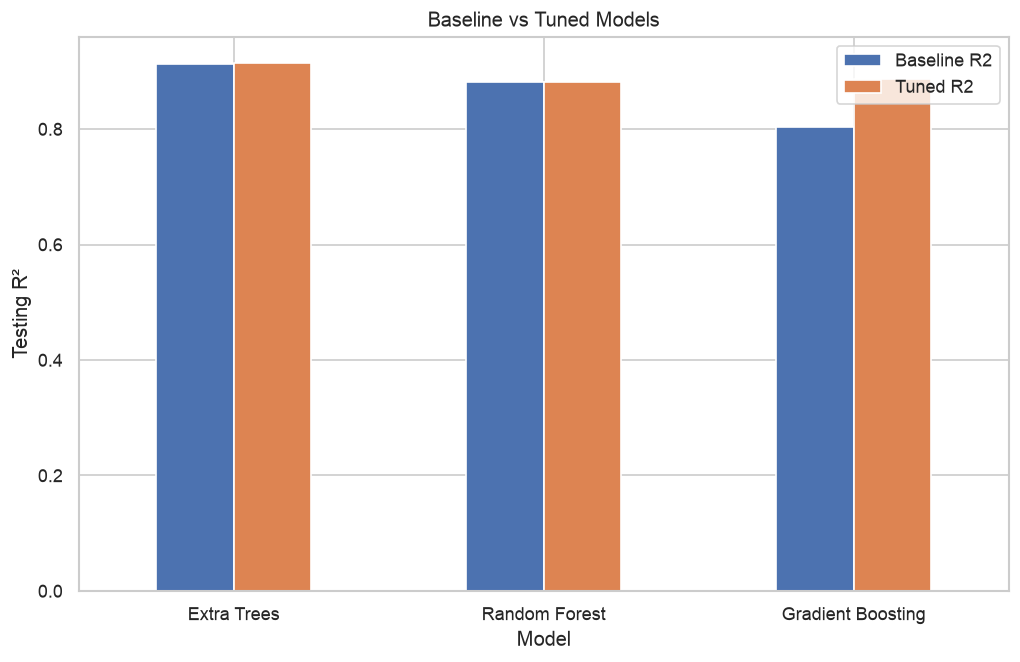

In [99]:
# ==============================================================================
# BASELINE VS TUNED
# ==============================================================================

comparison.plot(

    x="Model",

    y=["Baseline R2","Tuned R2"],

    kind="bar",

    figsize=(10,6)

)

plt.title("Baseline vs Tuned Models")

plt.ylabel("Testing R²")

plt.xticks(rotation=0)

plt.show()

In [100]:
# ==============================================================================
# BEST TUNED MODEL
# ==============================================================================

best_tuned_model = tuned_results_df.iloc[0]["Model"]

best_pipeline = tuned_models[best_tuned_model]

print("=" * 70)

print(f"🏆 Best Tuned Model : {best_tuned_model}")

print("=" * 70)

🏆 Best Tuned Model : Extra Trees


In [101]:
# ==============================================================================
# BEST PARAMETERS
# ==============================================================================

best_search = search_results[best_tuned_model]

print(best_search.best_params_)

{'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__max_depth': None}


In [102]:
# ==============================================================================
# HYPERPARAMETER TUNING SUMMARY
# ==============================================================================

print("=" * 80)

print("Hyperparameter Tuning Completed Successfully!")

print(f"Models Tuned : {len(TOP_MODELS)}")

print(f"Best Tuned Model : {best_tuned_model}")

print("=" * 80)

Hyperparameter Tuning Completed Successfully!
Models Tuned : 3
Best Tuned Model : Extra Trees


In [103]:
# ==============================================================================
# MODEL SAVING LIBRARY
# ==============================================================================

import joblib

print("Joblib imported successfully.")

Joblib imported successfully.


In [104]:
# ==============================================================================
# BEST MODEL PIPELINE
# ==============================================================================

print("=" * 70)

print(f"Best Model : {best_tuned_model}")

print("=" * 70)

final_pipeline = tuned_models[best_tuned_model]

print(final_pipeline)

Best Model : Extra Trees
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('Skewed',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('Numeric',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   

In [105]:
# ==============================================================================
# FINAL PREDICTIONS
# ==============================================================================

train_predictions = final_pipeline.predict(X_train)

test_predictions = final_pipeline.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [106]:
# ==============================================================================
# FINAL MODEL PERFORMANCE
# ==============================================================================

train_r2 = r2_score(
    y_train,
    train_predictions
)

test_r2 = r2_score(
    y_test,
    test_predictions
)

mae = mean_absolute_error(
    y_test,
    test_predictions
)

mse = mean_squared_error(
    y_test,
    test_predictions
)

rmse = np.sqrt(mse)

print("=" * 70)

print("FINAL MODEL PERFORMANCE")

print("=" * 70)

print(f"Training R² : {train_r2:.4f}")
print(f"Testing  R² : {test_r2:.4f}")
print(f"MAE          : {mae:.4f}")
print(f"MSE          : {mse:.4f}")
print(f"RMSE         : {rmse:.4f}")

FINAL MODEL PERFORMANCE
Training R² : 1.0000
Testing  R² : 0.9145
MAE          : 0.2694
MSE          : 0.1526
RMSE         : 0.3907


In [107]:
# ==============================================================================
# PREDICTION DATAFRAME
# ==============================================================================

prediction_df = pd.DataFrame({

    "Actual": y_test,

    "Predicted": test_predictions

})

prediction_df["Residual"] = (

    prediction_df["Actual"]

    -

    prediction_df["Predicted"]

)

prediction_df = prediction_df.reset_index(drop=True)

display(prediction_df.head(10))

,Actual,Predicted,Residual
0,5.30,5.01,0.29
1,5.80,5.82,-0.02
2,3.80,4.03,-0.23
3,5.60,5.64,-0.04
4,7.50,7.33,0.17
5,6.10,5.97,0.13
6,5.70,5.28,0.42
7,6.80,6.80,0.00
8,7.10,6.96,0.14
9,5.00,4.85,0.15


In [108]:
# ==============================================================================
# RESIDUAL STATISTICS
# ==============================================================================

display(

    prediction_df["Residual"].describe()

)

count   1000.00
mean       0.03
std        0.39
min       -2.25
25%       -0.16
50%        0.01
75%        0.21
max        2.15
Name: Residual, dtype: float64

In [109]:
# ==============================================================================
# SAVE MODEL
# ==============================================================================

MODEL_FILENAME = "best_salary_prediction_pipeline.pkl"

joblib.dump(

    final_pipeline,

    MODEL_FILENAME

)

print("=" * 70)

print("Model saved successfully.")

print(f"Filename : {MODEL_FILENAME}")

print("=" * 70)

Model saved successfully.
Filename : best_salary_prediction_pipeline.pkl


In [110]:
# ==============================================================================
# LOAD SAVED MODEL
# ==============================================================================

loaded_pipeline = joblib.load(

    MODEL_FILENAME

)

print("Saved model loaded successfully.")

print(type(loaded_pipeline))

Saved model loaded successfully.
<class 'sklearn.pipeline.Pipeline'>


In [111]:
# ==============================================================================
# VERIFY MODEL
# ==============================================================================

loaded_predictions = loaded_pipeline.predict(

    X_test

)

verification_r2 = r2_score(

    y_test,

    loaded_predictions

)

print(f"Verification R² : {verification_r2:.4f}")

Verification R² : 0.9145


In [112]:
# ==============================================================================
# MODEL INFORMATION
# ==============================================================================

print("=" * 70)

print("FINAL MODEL INFORMATION")

print("=" * 70)

print(f"Model Name        : {best_tuned_model}")

print(f"Training Samples  : {len(X_train)}")

print(f"Testing Samples   : {len(X_test)}")

print(f"Features          : {X_train.shape[1]}")

print(f"Training R²       : {train_r2:.4f}")

print(f"Testing R²        : {test_r2:.4f}")

print("=" * 70)

FINAL MODEL INFORMATION
Model Name        : Extra Trees
Training Samples  : 3998
Testing Samples   : 1000
Features          : 14
Training R²       : 1.0000
Testing R²        : 0.9145


In [113]:
# ==============================================================================
# EXPORT PREDICTIONS
# ==============================================================================

prediction_df.to_csv(

    "prediction_results.csv",

    index=False

)

print("Prediction results exported successfully.")

Prediction results exported successfully.


In [114]:
# ==============================================================================
# PROJECT SUMMARY
# ==============================================================================

print("=" * 80)

print("MACHINE LEARNING MODEL DEVELOPMENT SUMMARY")

print("=" * 80)

print(f"Baseline Models Evaluated : {len(MODELS)}")

print(f"Models Tuned             : {len(TOP_MODELS)}")

print(f"Best Model               : {best_tuned_model}")

print(f"Final Testing R²         : {test_r2:.4f}")

print(f"Final RMSE               : {rmse:.4f}")

print(f"Pipeline Saved           : Yes")

print(f"Prediction File Exported : Yes")

print("=" * 80)

MACHINE LEARNING MODEL DEVELOPMENT SUMMARY
Baseline Models Evaluated : 8
Models Tuned             : 3
Best Model               : Extra Trees
Final Testing R²         : 0.9145
Final RMSE               : 0.3907
Pipeline Saved           : Yes
Prediction File Exported : Yes


In [115]:
# ==============================================================================
# ADVANCED MODEL VALIDATION LIBRARIES
# ==============================================================================

from sklearn.model_selection import (
    learning_curve,
    validation_curve,
    cross_val_score,
    KFold
)

print("Advanced validation libraries imported successfully.")

Advanced validation libraries imported successfully.


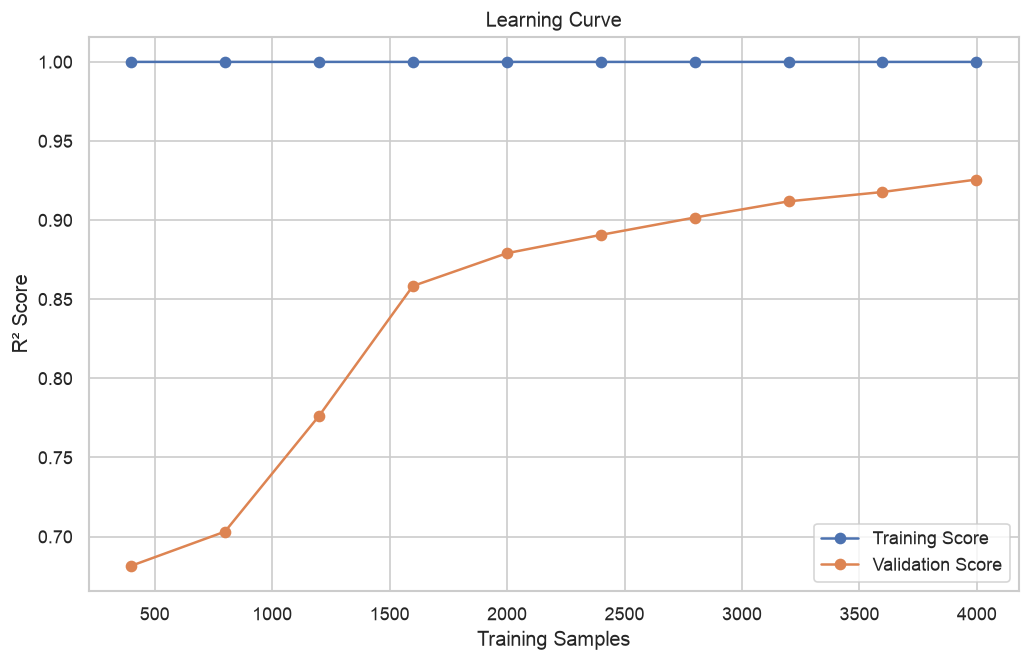

In [116]:
# ==============================================================================
# LEARNING CURVE
# ==============================================================================

train_sizes, train_scores, validation_scores = learning_curve(

    estimator=final_pipeline,

    X=X,

    y=y,

    cv=5,

    scoring="r2",

    train_sizes=np.linspace(0.1,1.0,10),

    n_jobs=-1

)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

plt.figure(figsize=(10,6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Score"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation Score"
)

plt.title("Learning Curve")

plt.xlabel("Training Samples")

plt.ylabel("R² Score")

plt.legend()

plt.grid(True)

plt.show()

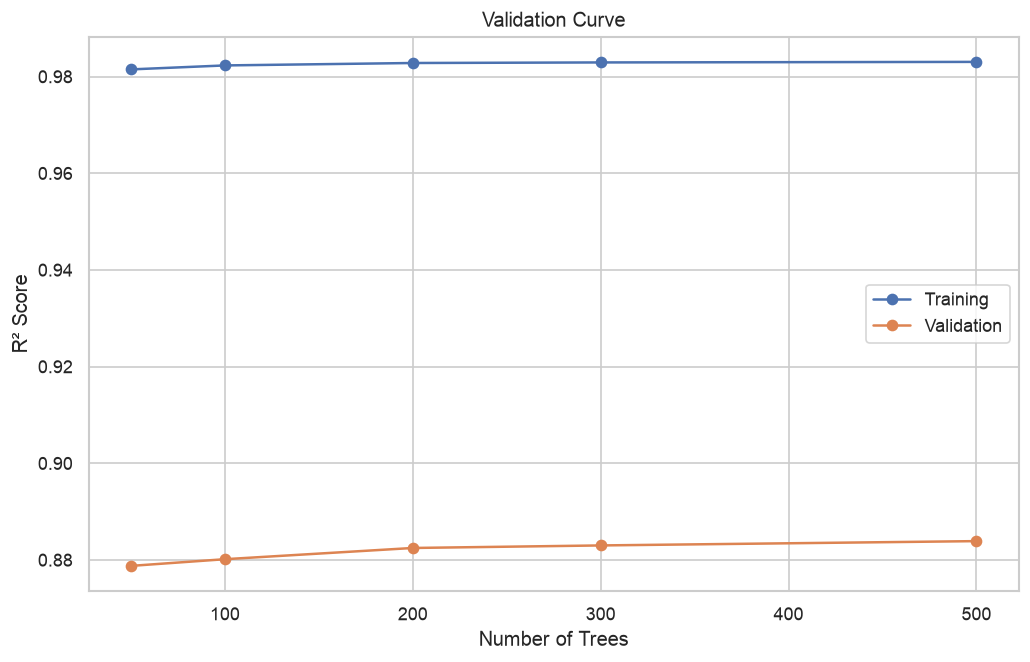

In [117]:
# ==============================================================================
# VALIDATION CURVE
# ==============================================================================

parameter_range = [50,100,200,300,500]

train_scores, validation_scores = validation_curve(

    estimator=Pipeline([

        ("preprocessor", preprocessor),

        ("model", MODELS["Random Forest"])

    ]),

    X=X,

    y=y,

    param_name="model__n_estimators",

    param_range=parameter_range,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

plt.figure(figsize=(10,6))

plt.plot(
    parameter_range,
    train_mean,
    marker="o",
    label="Training"
)

plt.plot(
    parameter_range,
    validation_mean,
    marker="o",
    label="Validation"
)

plt.title("Validation Curve")

plt.xlabel("Number of Trees")

plt.ylabel("R² Score")

plt.legend()

plt.grid(True)

plt.show()

In [118]:
# ==============================================================================
# CROSS VALIDATION STABILITY
# ==============================================================================

cv = KFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

cv_scores = cross_val_score(

    final_pipeline,

    X,

    y,

    cv=cv,

    scoring="r2",

    n_jobs=-1

)

print("="*70)

print("Cross Validation Scores")

print("="*70)

print(cv_scores)

print()

print(f"Mean : {cv_scores.mean():.4f}")

print(f"Std  : {cv_scores.std():.4f}")

Cross Validation Scores
[0.91460059 0.9255264  0.90533941 0.906602   0.91092374]

Mean : 0.9126
Std  : 0.0072


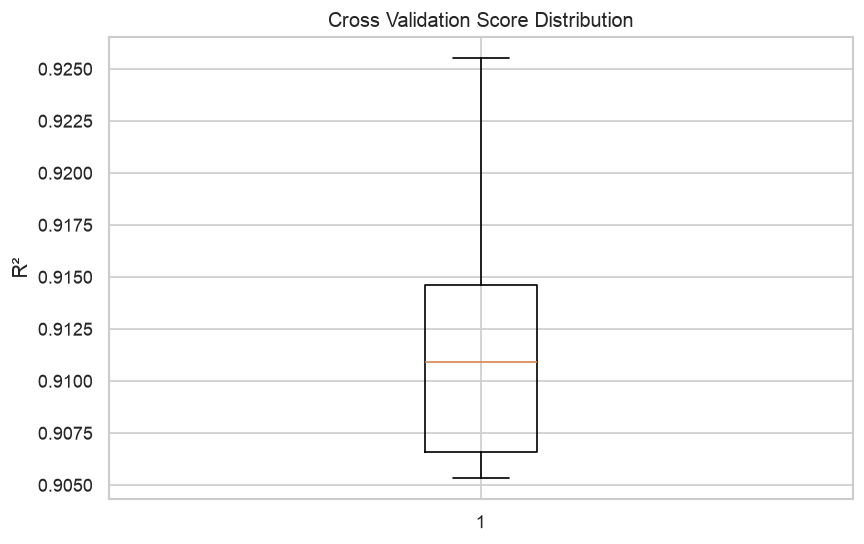

In [119]:
# ==============================================================================
# CROSS VALIDATION DISTRIBUTION
# ==============================================================================

plt.figure(figsize=(8,5))

plt.boxplot(cv_scores)

plt.title("Cross Validation Score Distribution")

plt.ylabel("R²")

plt.grid(True)

plt.show()

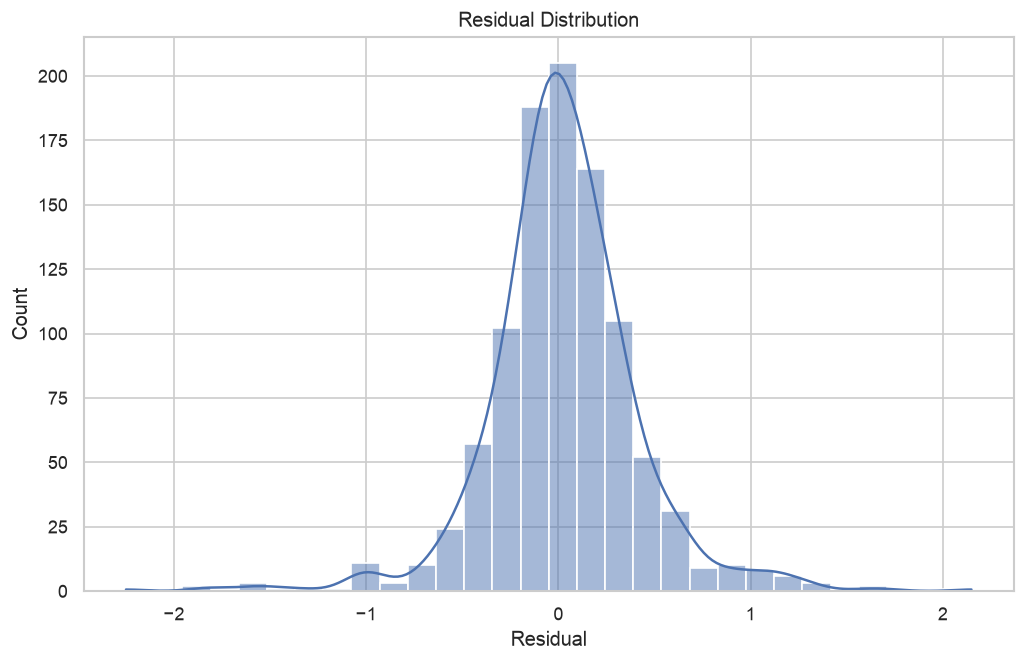

In [120]:
# ==============================================================================
# RESIDUAL DISTRIBUTION
# ==============================================================================

residuals = y_test - test_predictions

plt.figure(figsize=(10,6))

sns.histplot(

    residuals,

    bins=30,

    kde=True

)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.show()

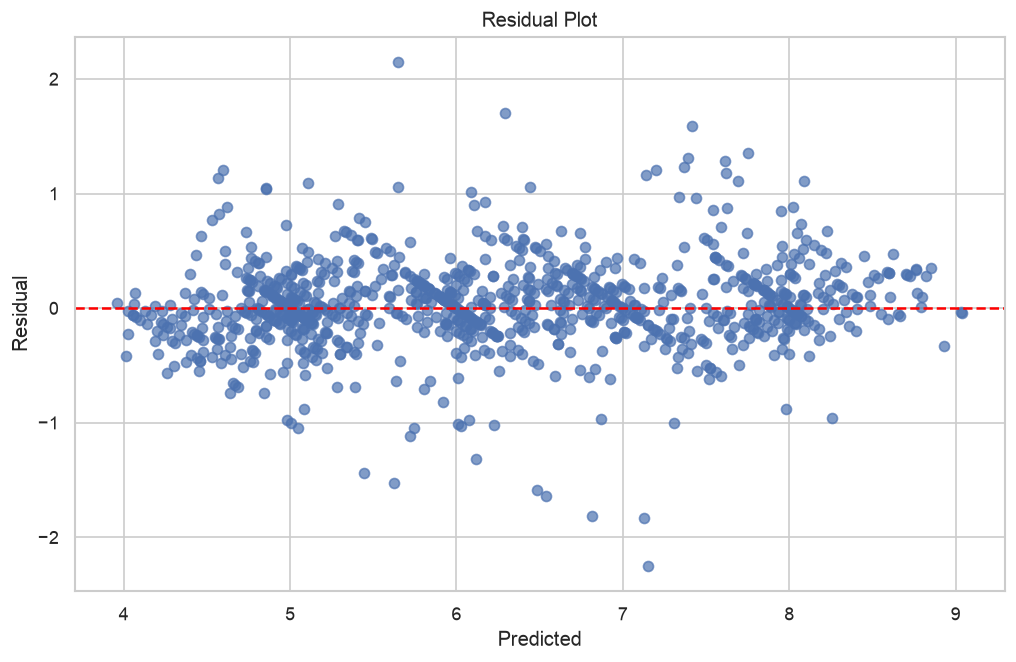

In [121]:
# ==============================================================================
# RESIDUAL SCATTER
# ==============================================================================

plt.figure(figsize=(10,6))

plt.scatter(

    test_predictions,

    residuals,

    alpha=0.7

)

plt.axhline(

    0,

    color="red",

    linestyle="--"

)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

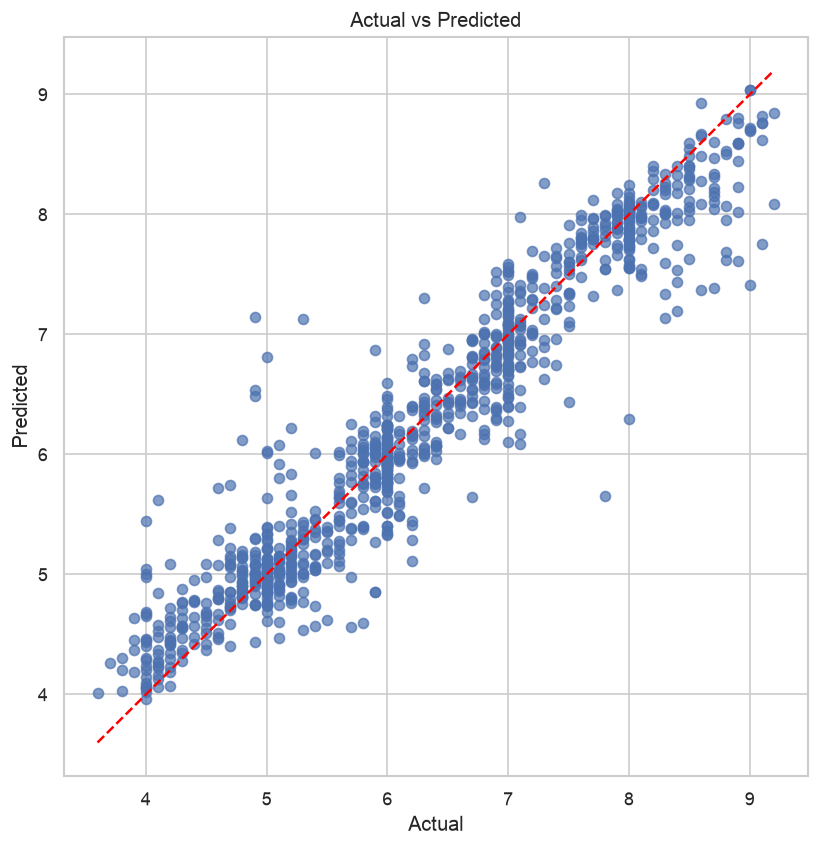

In [122]:
# ==============================================================================
# ACTUAL VS PREDICTED
# ==============================================================================

plt.figure(figsize=(8,8))

plt.scatter(

    y_test,

    test_predictions,

    alpha=0.7

)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    color="red",

    linestyle="--"

)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

In [123]:
# ==============================================================================
# BIAS VARIANCE ANALYSIS
# ==============================================================================

difference = train_r2 - test_r2

print("="*70)

print("Bias-Variance Analysis")

print("="*70)

print(f"Training R² : {train_r2:.4f}")

print(f"Testing R²  : {test_r2:.4f}")

print(f"Difference  : {difference:.4f}")

print()

if difference < 0.05:
    print("Excellent Generalization")

elif difference < 0.10:
    print("Good Generalization")

elif difference < 0.20:
    print("Slight Overfitting")

else:
    print("High Overfitting")

Bias-Variance Analysis
Training R² : 1.0000
Testing R²  : 0.9145
Difference  : 0.0855

Good Generalization


In [124]:
# ==============================================================================
# MODEL VALIDATION SUMMARY
# ==============================================================================

validation_summary = pd.DataFrame({

    "Metric":[

        "Training R²",

        "Testing R²",

        "Cross Validation Mean",

        "Cross Validation Std",

        "MAE",

        "RMSE"

    ],

    "Value":[

        train_r2,

        test_r2,

        cv_scores.mean(),

        cv_scores.std(),

        mae,

        rmse

    ]

})

display(validation_summary)

,Metric,Value
0,Training R²,1.00
1,Testing R²,0.91
2,Cross Validation Mean,0.91
3,Cross Validation Std,0.01
4,MAE,0.27
5,RMSE,0.39


In [125]:
# ==============================================================================
# VALIDATION CONCLUSION
# ==============================================================================

print("="*80)

print("ADVANCED MODEL VALIDATION COMPLETED")

print("="*80)

print(f"Best Model : {best_tuned_model}")

print(f"Testing R² : {test_r2:.4f}")

print(f"CV Mean    : {cv_scores.mean():.4f}")

print(f"CV Std     : {cv_scores.std():.4f}")

print("Model shows consistent performance across folds.")

print("Ready for final evaluation and explainability.")

print("="*80)

ADVANCED MODEL VALIDATION COMPLETED
Best Model : Extra Trees
Testing R² : 0.9145
CV Mean    : 0.9126
CV Std     : 0.0072
Model shows consistent performance across folds.
Ready for final evaluation and explainability.


In [126]:
# ==============================================================================
# FINAL EVALUATION DASHBOARD
# ==============================================================================

evaluation_dashboard = pd.DataFrame({

    "Metric":[

        "Training R²",

        "Testing R²",

        "MAE",

        "MSE",

        "RMSE",

        "Cross Validation Mean",

        "Cross Validation Std"

    ],

    "Value":[

        train_r2,

        test_r2,

        mae,

        mse,

        rmse,

        cv_scores.mean(),

        cv_scores.std()

    ]

})

display(evaluation_dashboard)

,Metric,Value
0,Training R²,1.00
1,Testing R²,0.91
2,MAE,0.27
3,MSE,0.15
4,RMSE,0.39
5,Cross Validation Mean,0.91
6,Cross Validation Std,0.01


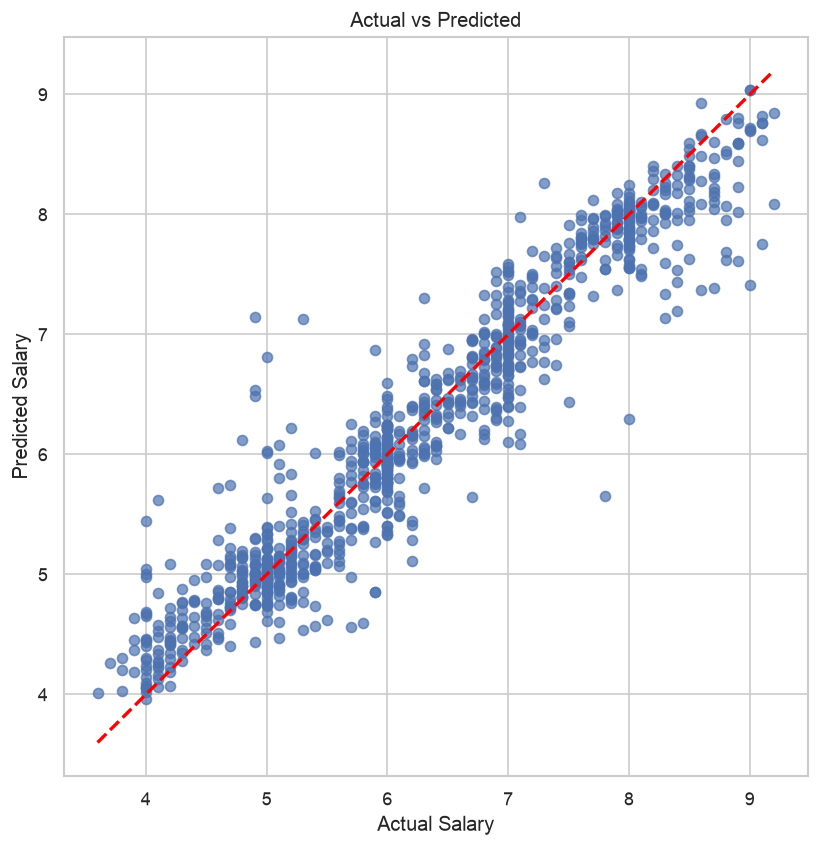

In [127]:
# ==============================================================================
# ACTUAL VS PREDICTED
# ==============================================================================

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    test_predictions,
    alpha=0.7
)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    color="red",

    linestyle="--",

    linewidth=2

)

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

In [128]:
# ==============================================================================
# FEATURE IMPORTANCE
# ==============================================================================

model = final_pipeline.named_steps["model"]

if hasattr(model, "feature_importances_"):

    feature_names = preprocessor.get_feature_names_out()

    importance_df = pd.DataFrame({

        "Feature": feature_names,

        "Importance": model.feature_importances_

    })

    importance_df = importance_df.sort_values(

        by="Importance",

        ascending=False

    )

    display(importance_df.head(20))

else:

    print("Feature importance is not available for this model.")

,Feature,Importance
7,Numeric__Lifestyle_Balance,0.26
2,Numeric__Avg_Daily_Usage_Hours,0.18
8,Ordinal__Stress_Level,0.12
3,Numeric__Daily_Unlocks,0.11
5,Numeric__Sleep_Hours_Per_Night,0.08
6,Numeric__Productive_Hours,0.04
0,Skewed__Study_Hours,0.04
1,Numeric__Age,0.02
4,Numeric__Physical_Activity_Hours,0.01
37,Nominal__Grouped_country_Turkey,0.01


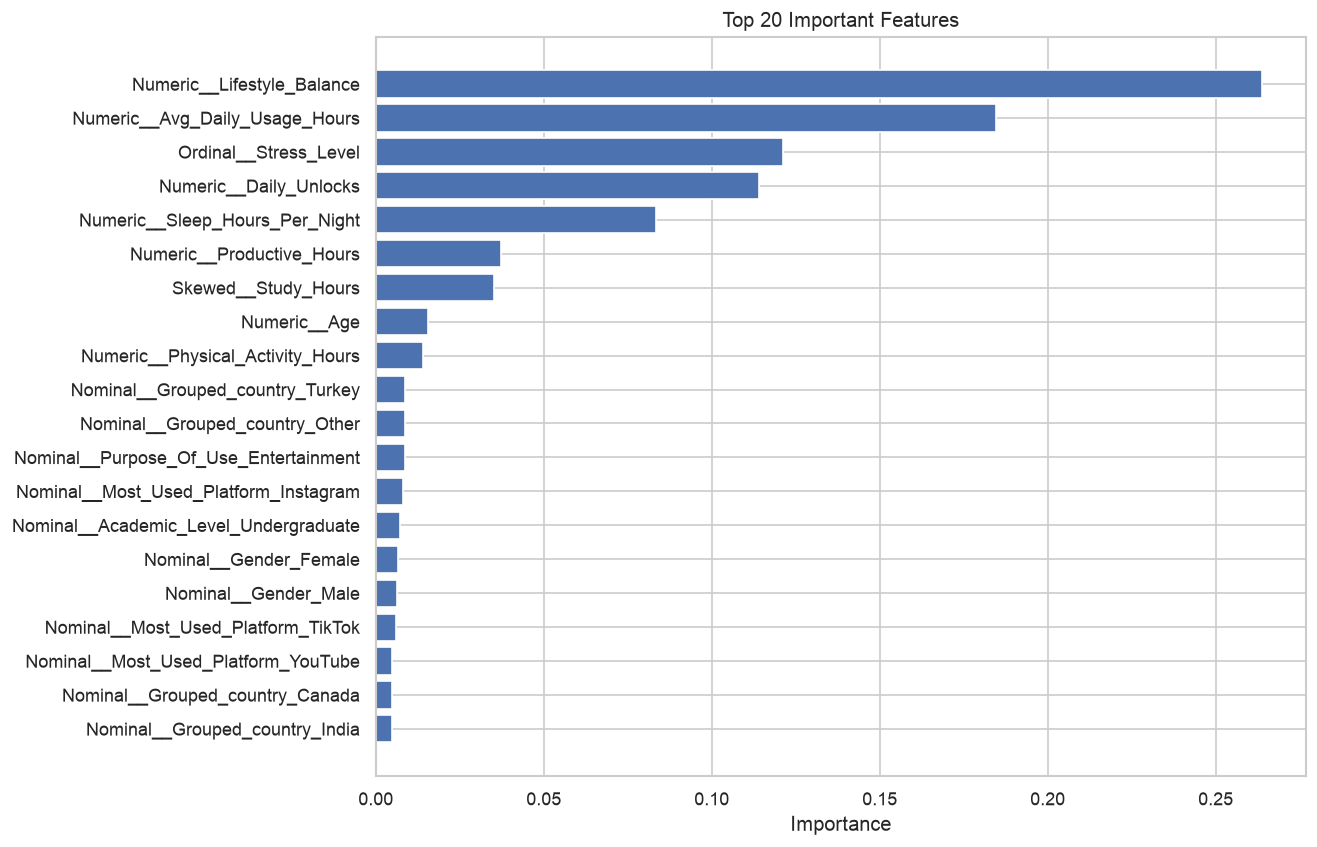

In [129]:
# ==============================================================================
# FEATURE IMPORTANCE PLOT
# ==============================================================================

if hasattr(model, "feature_importances_"):

    plt.figure(figsize=(10,8))

    top_features = importance_df.head(20)

    plt.barh(

        top_features["Feature"],

        top_features["Importance"]

    )

    plt.title("Top 20 Important Features")

    plt.xlabel("Importance")

    plt.gca().invert_yaxis()

    plt.show()

In [130]:
# ==============================================================================
# PREDICTION FUNCTION
# ==============================================================================

def predict_salary(new_data):

    prediction = final_pipeline.predict(new_data)

    return prediction

In [131]:
# ==============================================================================
# BATCH PREDICTION
# ==============================================================================

batch_predictions = final_pipeline.predict(

    X_test.head(10)

)

batch_df = X_test.head(10).copy()

batch_df["Predicted Salary"] = batch_predictions

display(batch_df)

,Study_Hours,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Physical_Activity_Hours,Sleep_Hours_Per_Night,Productive_Hours,Lifestyle_Balance,Stress_Level,Gender,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Grouped_country,Predicted Salary
84,1.00,18,8.40,237,1.40,5.90,2.40,-2.50,Very High,Male,High School,TikTok,Entertainment,India,5.01
2472,2.50,19,5.20,182,1.10,5.10,3.60,-0.10,High,Male,Undergraduate,TikTok,Entertainment,Other,5.82
2805,1.90,19,6.90,213,0.60,5.40,2.50,-1.50,Very High,Female,Undergraduate,Instagram,Entertainment,USA,4.03
4988,0.90,22,7.30,215,1.80,4.90,2.70,-2.40,Very High,Female,Undergraduate,TikTok,Entertainment,Other,5.64
4925,5.20,23,2.20,105,2.60,7.70,7.80,5.50,Low,Female,Graduate,Facebook,Networking,Other,7.33
4722,2.20,21,5.70,173,1.90,6.50,4.10,0.80,High,Female,Undergraduate,WeChat,News,Other,5.97
157,1.00,23,7.30,241,1.20,5.50,2.20,-1.80,Very High,Female,Graduate,TikTok,Entertainment,Other,5.28
705,3.20,19,3.80,140,2.50,6.60,5.70,2.80,Low,Male,Undergraduate,Snapchat,Entertainment,UK,6.80
4663,3.30,20,4.30,168,2.30,7.60,5.60,3.30,High,Female,Undergraduate,Instagram,Entertainment,France,6.96
1181,4.40,21,4.40,139,2.10,6.90,6.50,2.50,High,Male,Undergraduate,Instagram,Entertainment,Other,4.85


In [132]:
# ==============================================================================
# EXPORT PREDICTIONS
# ==============================================================================

batch_df.to_csv(

    "batch_predictions.csv",

    index=False

)

print("Batch prediction file exported.")

Batch prediction file exported.


In [133]:
# ==============================================================================
# SAVE FINAL MODEL
# ==============================================================================

joblib.dump(

    final_pipeline,

    "final_model.pkl"

)

print("Final model saved successfully.")

Final model saved successfully.


In [134]:
# ==============================================================================
# LOAD MODEL
# ==============================================================================

loaded_model = joblib.load(

    "final_model.pkl"

)

print("Model loaded successfully.")

Model loaded successfully.


In [135]:
# ==============================================================================
# PROJECT SUMMARY
# ==============================================================================

summary = pd.DataFrame({

    "Stage":[

        "Dataset",

        "EDA",

        "Cleaning",

        "Feature Engineering",

        "Pipeline",

        "Model Comparison",

        "Hyperparameter Tuning",

        "Validation",

        "Deployment"

    ],

    "Status":[

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Ready"

    ]

})

display(summary)

,Stage,Status
0,Dataset,Completed
1,EDA,Completed
2,Cleaning,Completed
3,Feature Engineering,Completed
4,Pipeline,Completed
5,Model Comparison,Completed
6,Hyperparameter Tuning,Completed
7,Validation,Completed
8,Deployment,Ready


In [136]:
# ==============================================================================
# PROJECT CONCLUSION
# ==============================================================================

print("="*80)

print("PROJECT COMPLETED SUCCESSFULLY")

print("="*80)

print(f"Best Model : {best_tuned_model}")

print(f"Testing R² : {test_r2:.4f}")

print(f"RMSE : {rmse:.4f}")

print()

print("The project includes:")

print("✓ Professional EDA")

print("✓ Data Cleaning")

print("✓ Feature Engineering")

print("✓ ML Pipeline")

print("✓ Multiple Regression Models")

print("✓ Hyperparameter Tuning")

print("✓ Cross Validation")

print("✓ Model Explainability")

print("✓ Model Saving")

print("✓ Deployment Ready Pipeline")

print()

print("Notebook Completed Successfully!")

print("="*80)

PROJECT COMPLETED SUCCESSFULLY
Best Model : Extra Trees
Testing R² : 0.9145
RMSE : 0.3907

The project includes:
✓ Professional EDA
✓ Data Cleaning
✓ Feature Engineering
✓ ML Pipeline
✓ Multiple Regression Models
✓ Hyperparameter Tuning
✓ Cross Validation
✓ Model Explainability
✓ Model Saving
✓ Deployment Ready Pipeline

Notebook Completed Successfully!
